<a href="https://colab.research.google.com/github/1kaiser/Media-Segment-Depth-MLP/blob/main/nnx_string3d_experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [50]:
# @title ##GRAINet dataset downloading
%cd /content/

!wget -nc -q https://github.com/1kaiser/GRAINet/releases/download/1/input_depth.zip
!unzip -o /content/input_depth.zip > /dev/null 2>&1

# Create project structure
!rm -rf vision_transformer_depth/data
!mkdir -p vision_transformer_depth/data
!mv /content/inputimage vision_transformer_depth/data/input_frames
!mv /content/depthimage vision_transformer_depth/data/depth_maps

%cd /content/vision_transformer_depth

/content
/content/vision_transformer_depth


In [27]:
# @title ### frame dataset downloading
# Run this in a Colab cell FIRST to get your data
%cd /content/

!wget -nc -q https://github.com/1kaiser/Media-Segment-Depth-MLP/releases/download/v0.2/input_depthMaps.zip
!unzip -o /content/input_depthMaps.zip > /dev/null 2>&1

# Create project structure
!rm -rf vision_transformer_depth/data
!mkdir -p vision_transformer_depth/data
!mv input_frames vision_transformer_depth/data/
!mv depth_maps vision_transformer_depth/data/

%cd /content/vision_transformer_depth

/content
/content/vision_transformer_depth


In [ ]:
# @title ### satellite data downloading
import glob
import os
from osgeo import gdal

BASE_URL = "https://github.com/1kaiser/APPEEAR-LDDAC-DATA-DOWNLOAD/releases/download/1"

# Download files
print("⬇️ Downloading files...")
!rm -f /content/vision_transformer_depth/DigitalElevationModel_01.tif /content/folder01_part_*
!wget -nc --no-check-certificate -P /content/vision_transformer_depth {BASE_URL}/DigitalElevationModel_01.tif
!wget -nc --no-check-certificate -P /content {BASE_URL}/folder01_part_aa
!wget -nc --no-check-certificate -P /content {BASE_URL}/folder01_part_ab

# Extract and organize
print("📦 Extracting images...")
!cat /content/folder01_part_* > /content/folder01.zip
!rm -f /content/folder01_part_*
!mkdir -p /content/imagesfolder
!unzip -oq /content/folder01.zip -d /content/imagesfolder
!rm -f /content/folder01.zip
!mv /content/imagesfolder/files/* /content/imagesfolder/ 2>/dev/null || true

# Resample DEM
print("🗺️ Resampling DEM...")
try:
    sample_tif = glob.glob('/content/imagesfolder/*.tif')[0]
    ref_ds = gdal.Open(sample_tif)
    if ref_ds is None:
        raise RuntimeError(f"Failed to open: {sample_tif}")

    width, height = ref_ds.RasterXSize, ref_ds.RasterYSize
    ref_ds = None

    print(f"Target size: {width}x{height}")
    gdal.Warp('/content/DEMx.tif',
              '/content/vision_transformer_depth/DigitalElevationModel_01.tif',
              width=width, height=height, resampleAlg='bilinear')

except Exception as e:
    print(f"⚠️ Resampling failed: {e}. Using original DEM.")
    !cp /content/vision_transformer_depth/DigitalElevationModel_01.tif /content/DEMx.tif

# Verify
if not os.path.exists('/content/DEMx.tif'):
    raise RuntimeError("FATAL: DEMx.tif not created")

print("✅ Data acquisition complete")
!uv pip install -q opencv-python
import os
import glob
import numpy as np
from osgeo import gdal
import cv2

print("--- Starting Satellite Data Preparation ---")

# Configuration
data_dir_path = '/content/vision_transformer_depth/data'
satellite_image_dir = '/content/imagesfolder/'
dem_path = '/content/DEMx.tif'
rgb_bands_numbers = ["b05", "b04", "b03"]
image_size = 224

# Setup directories
print("🧹 Setting up directories...")
if os.path.exists(data_dir_path):
    !rm -rf {data_dir_path}/*
os.makedirs(data_dir_path, exist_ok=True)
output_frames_dir = os.path.join(data_dir_path, 'input_frames')
output_depth_dir = os.path.join(data_dir_path, 'depth_maps')
os.makedirs(output_frames_dir, exist_ok=True)
os.makedirs(output_depth_dir, exist_ok=True)

# Helper functions
def gdal_to_numpy(path, xoff=0, yoff=0, xsize=None, ysize=None):
    raster_ds = gdal.Open(path)
    if raster_ds is None:
        raise FileNotFoundError(f"GDAL failed to open: {path}")
    return raster_ds.ReadAsArray(xoff, yoff, xsize, ysize).astype(np.float32)

def normalize(band):
    return (band - band.min()) / (band.max() - band.min()) if band.max() > band.min() else np.zeros_like(band)

# Determine dimensions
print("⬇️ Determining dimensions...")
sample_path = glob.glob(os.path.join(satellite_image_dir, f'*{rgb_bands_numbers[0]}*.tif'))[0]
img_h, img_w = gdal_to_numpy(sample_path).shape[:2]
dep_h, dep_w = gdal_to_numpy(dem_path).shape[:2]
min_height, min_width = min(img_h, dep_h), min(img_w, dep_w)
num_rows, num_cols = min_height // image_size, min_width // image_size
print(f"Tiles: {num_cols}x{num_rows} = {num_cols * num_rows}")

# Process tiles
print("Processing tiles...")
tile_count = 0
for row_idx in range(num_rows):
    for col_idx in range(num_cols):
        row_start, col_start = row_idx * image_size, col_idx * image_size

        try:
            # Extract and normalize depth
            depth_tile = gdal_to_numpy(dem_path, col_start, row_start, image_size, image_size)
            depth_norm = normalize(depth_tile)

            # Extract and stack RGB bands
            bands = []
            for band_num in rgb_bands_numbers:
                band_file = glob.glob(os.path.join(satellite_image_dir, f'*{band_num}*.tif'))[0]
                band_data = gdal_to_numpy(band_file, col_start, row_start, image_size, image_size)
                if band_data.shape != (image_size, image_size):
                    raise ValueError(f"Incorrect shape for {band_num}")
                bands.append(band_data)

            rgb_tile = np.stack(bands, axis=-1)

            # Save tiles
            rgb_scaled = (normalize(rgb_tile) * 255).astype(np.uint8)
            depth_scaled = (depth_norm * 255).astype(np.uint8)

            cv2.imwrite(f'{output_frames_dir}/frame_{tile_count:04d}.png',
                       cv2.cvtColor(rgb_scaled, cv2.COLOR_RGB2BGR))
            cv2.imwrite(f'{output_depth_dir}/frame_{tile_count:04d}.png', depth_scaled)

            tile_count += 1

        except Exception as e:
            print(f"Skipping tile ({row_idx},{col_idx}): {e}")
            continue

print(f"--- Processed {tile_count} tiles ---")

# Verify
print("\n--- Verification ---")
num_images = len(os.listdir(output_frames_dir))
num_depths = len(os.listdir(output_depth_dir))
print(f"Images: {num_images}, Depths: {num_depths}")
print("✅ Success" if num_images == num_depths > 0 else "❌ Mismatch")
print("--- Complete ---")

⬇️ Downloading files...
--2025-10-05 07:22:54--  https://github.com/1kaiser/APPEEAR-LDDAC-DATA-DOWNLOAD/releases/download/1/DigitalElevationModel_01.tif
Resolving github.com (github.com)... 140.82.116.4
Connecting to github.com (github.com)|140.82.116.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/570306733/b4739f92-70b3-43e8-97e0-fac3d7a1be36?sp=r&sv=2018-11-09&sr=b&spr=https&se=2025-10-05T08%3A00%3A43Z&rscd=attachment%3B+filename%3DDigitalElevationModel_01.tif&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2025-10-05T07%3A00%3A19Z&ske=2025-10-05T08%3A00%3A43Z&sks=b&skv=2018-11-09&sig=pc7%2BalMe09vnylUfdm0GR9%2Bdx0r38jY7anOXNcX3m3o%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc1OTY1MjU3NSwib

# nnx_string3d_experiment_pipeline

In [28]:
# @title ### Cell 1: Setup and Dependencies
!pip install -q flax jax jaxlib optax einops grain opencv-python matplotlib tqdm

import os
import pickle
import cv2
import numpy as np
import matplotlib.pyplot as plt
import glob
from typing import Optional, Tuple, Dict, List

import jax
import jax.numpy as jnp
from jax import random

import flax.nnx as nnx
import optax
import grain
from einops import rearrange
from tqdm import trange

print("✅ Dependencies installed")
print(f"JAX version: {jax.__version__}")
print(f"Devices: {jax.devices()}")

✅ Dependencies installed
JAX version: 0.5.3
Devices: [TpuDevice(id=0, process_index=0, coords=(0,0,0), core_on_chip=0)]


In [29]:
# @title ### Cell 2: Data Loading (unchanged, works correctly)
class DepthDataSource:
    """Data source for loading RGB images and corresponding depth maps."""

    def __init__(self, data_dir: str = "."):
        self.pairs = [
            (f, os.path.join(data_dir, "depth_maps", os.path.basename(f)))
            for f in glob.glob(os.path.join(data_dir, "input_frames", "*.png"))
            if os.path.exists(os.path.join(data_dir, "depth_maps", os.path.basename(f)))
        ]

    def __len__(self) -> int:
        return len(self.pairs)

    def __getitem__(self, idx: int) -> Dict[str, jnp.ndarray]:
        inp_path, dep_path = self.pairs[idx]

        inp_rgb = cv2.cvtColor(cv2.imread(inp_path), cv2.COLOR_BGR2RGB)
        dep = cv2.imread(dep_path, cv2.IMREAD_GRAYSCALE)

        inp_rgb = inp_rgb.astype(np.float32) / 255.0
        dep = dep.astype(np.float32) / 255.0

        h, w, _ = inp_rgb.shape
        y = max(0, (h - 224) // 2)
        x = max(0, (w - 224) // 2)

        return {
            'image': inp_rgb[y:y+224, x:x+224],
            'depth': dep[y:y+224, x:x+224][..., None]
        }


def create_data_iterator(data_dir: str, batch_size: int, seed: int = 42):
    source = DepthDataSource(data_dir=data_dir)
    if not source.pairs:
        return iter([])

    return iter(
        grain.MapDataset.source(source)
        .shuffle(seed=seed)
        .batch(batch_size, drop_remainder=True)
        .repeat()
        .to_iter_dataset()
    )

print("✅ Data loading ready")

✅ Data loading ready


In [30]:
# @title ### Cell 3: Circulant-STRING (Correct Implementation)
class CirculantSTRING2D(nnx.Module):
    """Circulant-STRING using FFT for O(d log d) complexity.

    Based on paper Theorem 3.5: Uses eigendecomposition of circulant matrices.
    """

    def __init__(self, embed_dim: int, rngs: nnx.Rngs):
        """
        Args:
            embed_dim: Embedding dimension (head dimension in multi-head attention)
            rngs: Random number generators
        """
        self.embed_dim = embed_dim

        # Learnable circulant matrices (only first row needed - paper Eq. 11)
        # One for x-axis, one for y-axis
        self.c_x = nnx.Param(
            nnx.initializers.normal(stddev=0.01)(rngs.params(), (embed_dim,))
        )
        self.c_y = nnx.Param(
            nnx.initializers.normal(stddev=0.01)(rngs.params(), (embed_dim,))
        )

    def _apply_circulant_transform(
        self,
        x: jnp.ndarray,  # (batch, n_heads, seq, head_dim)
        c: jnp.ndarray,  # (head_dim,)
        coord: jnp.ndarray  # (seq,)
    ) -> jnp.ndarray:
        """Apply exp(L * coord) where L = Circulant(c) - Circulant(c)^T.

        Uses FFT eigendecomposition (paper Theorem 3.5).
        """
        # 1. Get eigenvalues of circulant matrix via FFT
        c_fft = jnp.fft.fft(c)

        # 2. Eigenvalues of circulant transpose (reversed first row)
        c_rev = jnp.concatenate([c[:1], c[:0:-1]])
        c_rev_fft = jnp.fft.fft(c_rev)

        # 3. Antisymmetric part: L = C - C^T
        L_eigenvalues = c_fft - c_rev_fft

        # 4. Matrix exponential via eigenvalues: exp(L * coord)
        # Shape: (seq, head_dim)
        exp_L_eigenvalues = jnp.exp(L_eigenvalues[None, :] * coord[:, None])

        # 5. Apply transformation using FFT
        # Transform to Fourier basis
        x_fft = jnp.fft.fft(x, axis=-1)

        # Multiply by exp(L) eigenvalues (broadcast over batch and heads)
        x_transformed_fft = x_fft * exp_L_eigenvalues[None, None, :, :]

        # Transform back to spatial domain
        x_transformed = jnp.fft.ifft(x_transformed_fft, axis=-1).real

        return x_transformed

    def __call__(
        self,
        x: jnp.ndarray,  # (batch, n_heads, seq, head_dim)
        h_patches: int,
        w_patches: int
    ) -> jnp.ndarray:
        """Apply 2D circulant-STRING position encoding.

        Args:
            x: Input queries or keys (batch, n_heads, seq, head_dim)
            h_patches: Number of patches in height
            w_patches: Number of patches in width

        Returns:
            Position-encoded tensor (batch, n_heads, seq, head_dim)
        """
        # Generate 2D grid coordinates (excluding CLS token at position 0)
        y_grid, x_grid = jnp.meshgrid(
            jnp.arange(h_patches),
            jnp.arange(w_patches),
            indexing='ij'
        )

        # Flatten and add CLS token at origin
        x_coords = jnp.concatenate([jnp.zeros(1), x_grid.flatten() + 1])
        y_coords = jnp.concatenate([jnp.zeros(1), y_grid.flatten() + 1])

        # Normalize to [-1, 1] range
        x_coords = (x_coords / max(w_patches, 1)) * 2 - 1
        y_coords = (y_coords / max(h_patches, 1)) * 2 - 1

        # Apply circulant transformations sequentially for x and y
        # Paper Eq. 6: exp(L_x * x + L_y * y) = exp(L_x * x) @ exp(L_y * y)
        x_encoded_x = self._apply_circulant_transform(x, self.c_x.value, x_coords)
        x_encoded_xy = self._apply_circulant_transform(x_encoded_x, self.c_y.value, y_coords)

        return x_encoded_xy

print("✅ Circulant-STRING implemented")

✅ Circulant-STRING implemented


In [31]:
# @title ### Cell 4: Cayley-STRING (Correct Implementation)
class CayleySTRING2D(nnx.Module):
    """Cayley-STRING using Cayley transform for orthogonal matrix.

    Based on paper Eq. 10 and Theorem 3.4.
    """

    def __init__(self, embed_dim: int, rngs: nnx.Rngs):
        """
        Args:
            embed_dim: Embedding dimension (must be even)
            rngs: Random number generators
        """
        if embed_dim % 2 != 0:
            raise ValueError(f"embed_dim must be even, got {embed_dim}")

        self.embed_dim = embed_dim
        self.n_freq = embed_dim // 2

        # Learnable antisymmetric matrix for Cayley transform (paper Eq. 10)
        S_init = nnx.initializers.normal(stddev=0.01)(
            rngs.params(), (embed_dim, embed_dim)
        )
        self.S = nnx.Param(S_init)

        # Learnable rotation frequencies (paper: angle-defining frequencies)
        self.freqs = nnx.Param(
            jnp.ones(self.n_freq) / 10000.0
        )

    def _cayley_transform(self, S: jnp.ndarray) -> jnp.ndarray:
        """Compute orthogonal matrix via Cayley transform: Q = (I - S)(I + S)^-1.

        Paper Eq. 10.
        """
        # Make antisymmetric
        S_antisym = (S - S.T) / 2.0
        I = jnp.eye(self.embed_dim)

        # Cayley transform: Q = (I - S)(I + S)^-1
        Q = jnp.linalg.solve(I + S_antisym, I - S_antisym)

        return Q

    def _apply_block_rotations(
        self,
        x: jnp.ndarray,  # (batch, n_heads, seq, head_dim)
        angles: jnp.ndarray  # (seq, n_freq)
    ) -> jnp.ndarray:
        """Apply 2D rotations in d/2 2D subspaces.

        This is the Λ(coord) matrix from paper Eq. 9.
        """
        batch, n_heads, seq, d = x.shape

        # Reshape to expose 2D rotation pairs: (batch, n_heads, seq, n_freq, 2)
        x_pairs = x.reshape(batch, n_heads, seq, self.n_freq, 2)

        cos_vals = jnp.cos(angles)  # (seq, n_freq)
        sin_vals = jnp.sin(angles)

        # Apply 2D rotation matrix [[cos, -sin], [sin, cos]]
        x1, x2 = x_pairs[..., 0], x_pairs[..., 1]

        x_rot_1 = cos_vals[None, None, :, :] * x1 - sin_vals[None, None, :, :] * x2
        x_rot_2 = sin_vals[None, None, :, :] * x1 + cos_vals[None, None, :, :] * x2

        x_rotated = jnp.stack([x_rot_1, x_rot_2], axis=-1)

        return x_rotated.reshape(batch, n_heads, seq, d)

    def __call__(
        self,
        x: jnp.ndarray,  # (batch, n_heads, seq, head_dim)
        h_patches: int,
        w_patches: int
    ) -> jnp.ndarray:
        """Apply 2D Cayley-STRING position encoding.

        Paper Eq. 9: M(coord) = Q @ exp(Λ(coord)) @ Q^T
        where Q is orthogonal (Cayley transform) and Λ is block-diagonal rotations.
        """
        batch, n_heads, seq, d = x.shape

        # Generate 2D grid coordinates
        y_grid, x_grid = jnp.meshgrid(
            jnp.arange(h_patches),
            jnp.arange(w_patches),
            indexing='ij'
        )

        x_coords = jnp.concatenate([jnp.zeros(1), x_grid.flatten() + 1])
        y_coords = jnp.concatenate([jnp.zeros(1), y_grid.flatten() + 1])

        # Normalize coordinates
        x_coords = (x_coords / max(w_patches, 1)) * 2 - 1
        y_coords = (y_coords / max(h_patches, 1)) * 2 - 1

        # Compute rotation angles for each position
        # angles = freq * (x + y) for each frequency
        angles = (
            x_coords[:, None] * self.freqs[None, :] +
            y_coords[:, None] * self.freqs[None, :]
        )  # (seq, n_freq)

        # 1. Apply block-diagonal rotations: exp(Λ(coord))
        x_rotated = self._apply_block_rotations(x, angles)

        # 2. Change of basis via Cayley transform: Q @ x @ Q^T
        Q = self._cayley_transform(self.S.value)

        # Apply Q: reshape to (batch*n_heads*seq, d) for matrix multiply
        x_flat = x_rotated.reshape(-1, d)
        x_transformed = (x_flat @ Q.T).reshape(batch, n_heads, seq, d)

        return x_transformed

print("✅ Cayley-STRING implemented")

✅ Cayley-STRING implemented


In [32]:
# @title ### Cell 5: Multi-Head Attention with STRING
class STRING2DAttention(nnx.Module):
    """Multi-head attention with STRING position encoding.

    Key difference from your code: STRING is applied to Q and K, not input tokens.
    """

    def __init__(
        self,
        num_heads: int,
        embed_dim: int,
        rngs: nnx.Rngs,
        string_type: str = "cayley"  # "cayley" or "circulant"
    ):
        self.num_heads = num_heads
        self.embed_dim = embed_dim
        self.head_dim = embed_dim // num_heads
        self.string_type = string_type

        # Standard attention projections
        self.qkv = nnx.Linear(embed_dim, embed_dim * 3, use_bias=False, rngs=rngs)
        self.out_proj = nnx.Linear(embed_dim, embed_dim, rngs=rngs)

        # STRING encoder (applied per head)
        if string_type == "cayley":
            self.string_encoder = CayleySTRING2D(self.head_dim, rngs=rngs)
        elif string_type == "circulant":
            self.string_encoder = CirculantSTRING2D(self.head_dim, rngs=rngs)
        else:
            raise ValueError(f"Unknown STRING type: {string_type}")

    def __call__(
        self,
        x: jnp.ndarray,  # (batch, seq, embed_dim)
        h_patches: int,
        w_patches: int
    ) -> jnp.ndarray:
        batch, seq, _ = x.shape

        # Generate Q, K, V
        qkv = self.qkv(x)
        q, k, v = jnp.split(qkv, 3, axis=-1)

        # Reshape for multi-head: (batch, seq, num_heads, head_dim) -> (batch, num_heads, seq, head_dim)
        q = q.reshape(batch, seq, self.num_heads, self.head_dim).transpose(0, 2, 1, 3)
        k = k.reshape(batch, seq, self.num_heads, self.head_dim).transpose(0, 2, 1, 3)
        v = v.reshape(batch, seq, self.num_heads, self.head_dim).transpose(0, 2, 1, 3)

        # CRITICAL: Apply STRING to queries and keys (paper Eq. 1-4)
        q_encoded = self.string_encoder(q, h_patches, w_patches)
        k_encoded = self.string_encoder(k, h_patches, w_patches)

        # Scaled dot-product attention
        scores = (q_encoded @ k_encoded.transpose(0, 1, 3, 2)) / jnp.sqrt(self.head_dim)
        attn_weights = nnx.softmax(scores, axis=-1)

        # Apply attention to values
        output = attn_weights @ v

        # Reshape back: (batch, num_heads, seq, head_dim) -> (batch, seq, embed_dim)
        output = output.transpose(0, 2, 1, 3).reshape(batch, seq, self.embed_dim)

        return self.out_proj(output)

print("✅ STRING Attention implemented")

✅ STRING Attention implemented


In [33]:
# @title ### Cell 6: Transformer Block with STRING
class STRINGTransformerBlock(nnx.Module):
    """Transformer block using STRING attention."""

    def __init__(
        self,
        embed_dim: int,
        num_heads: int,
        rngs: nnx.Rngs,
        string_type: str = "cayley"
    ):
        self.embed_dim = embed_dim

        # Layers
        self.norm1 = nnx.LayerNorm(embed_dim, rngs=rngs)
        self.attention = STRING2DAttention(
            num_heads=num_heads,
            embed_dim=embed_dim,
            rngs=rngs,
            string_type=string_type
        )
        self.norm2 = nnx.LayerNorm(embed_dim, rngs=rngs)
        self.mlp_fc1 = nnx.Linear(embed_dim, embed_dim * 4, rngs=rngs)
        self.mlp_fc2 = nnx.Linear(embed_dim * 4, embed_dim, rngs=rngs)
        self.dropout = nnx.Dropout(rate=0.1, rngs=rngs)

    def __call__(
        self,
        x: jnp.ndarray,
        h_patches: int,
        w_patches: int,
        train: bool = True
    ) -> jnp.ndarray:
        # Attention with residual
        attn_out = self.attention(self.norm1(x), h_patches, w_patches)
        attn_out = self.dropout(attn_out, deterministic=not train)
        x = x + attn_out

        # MLP with residual
        mlp_out = self.norm2(x)
        mlp_out = self.mlp_fc1(mlp_out)
        mlp_out = nnx.gelu(mlp_out)
        mlp_out = self.dropout(mlp_out, deterministic=not train)
        mlp_out = self.mlp_fc2(mlp_out)
        mlp_out = self.dropout(mlp_out, deterministic=not train)
        x = x + mlp_out

        return x

print("✅ Transformer block with STRING ready")

✅ Transformer block with STRING ready


In [34]:
# @title ### Cell 7 (FIXED): Adaptive Depth Head for Non-Square Grids

class DepthHead(nnx.Module):
    """Decoder for depth map reconstruction - handles non-square grids."""

    def __init__(self, embed_dim: int, rngs: nnx.Rngs):
        self.proj = nnx.Linear(embed_dim, 256, rngs=rngs)

        self.upsample1 = nnx.ConvTranspose(256, 128, kernel_size=(2, 2), strides=(2, 2), rngs=rngs)
        self.conv1 = nnx.Conv(128, 128, kernel_size=(3, 3), padding=1, rngs=rngs)

        self.upsample2 = nnx.ConvTranspose(128, 64, kernel_size=(2, 2), strides=(2, 2), rngs=rngs)
        self.conv2 = nnx.Conv(64, 64, kernel_size=(3, 3), padding=1, rngs=rngs)

        self.upsample3 = nnx.ConvTranspose(64, 32, kernel_size=(2, 2), strides=(2, 2), rngs=rngs)
        self.conv3 = nnx.Conv(32, 32, kernel_size=(3, 3), padding=1, rngs=rngs)

        self.upsample4 = nnx.ConvTranspose(32, 16, kernel_size=(2, 2), strides=(2, 2), rngs=rngs)
        self.conv4 = nnx.Conv(16, 16, kernel_size=(3, 3), padding=1, rngs=rngs)

        self.final_conv = nnx.Conv(16, 1, kernel_size=(1, 1), rngs=rngs)

    def __call__(
        self,
        patch_features: jnp.ndarray,
        h_patches: int,
        w_patches: int
    ) -> jnp.ndarray:
        """
        Args:
            patch_features: (batch, n_patches, embed_dim)
            h_patches: number of patches in height
            w_patches: number of patches in width
        """
        x = self.proj(patch_features)

        # FIXED: Use actual grid dimensions instead of sqrt
        x = x.reshape(x.shape[0], h_patches, w_patches, 256)

        x = self.upsample1(x)
        x = nnx.relu(self.conv1(x))

        x = self.upsample2(x)
        x = nnx.relu(self.conv2(x))

        x = self.upsample3(x)
        x = nnx.relu(self.conv3(x))

        x = self.upsample4(x)
        x = nnx.relu(self.conv4(x))

        x = self.final_conv(x)
        x = nnx.sigmoid(x)

        return x

print("✅ Fixed depth head ready")

✅ Fixed depth head ready


In [35]:
# @title ### Cell 8 (UPDATED): Full ViT Model - Pass Grid Dimensions

class ViTForDepth_STRING(nnx.Module):
    """Vision Transformer with STRING for depth estimation."""

    def __init__(
        self,
        patch_size: int,
        num_layers: int,
        embed_dim: int,
        num_heads: int,
        rngs: nnx.Rngs,
        string_type: str = "cayley"
    ):
        self.patch_size = patch_size
        self.num_layers = num_layers
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.string_type = string_type

        # Patch embedding
        self.patch_embed = nnx.Conv(
            in_features=3,
            out_features=embed_dim,
            kernel_size=(patch_size, patch_size),
            strides=(patch_size, patch_size),
            rngs=rngs
        )

        # CLS token
        self.cls_token = nnx.Param(
            nnx.initializers.normal(stddev=0.02)(rngs.params(), (1, 1, embed_dim))
        )

        # Dropout
        self.dropout = nnx.Dropout(rate=0.1, rngs=rngs)

        # Transformer blocks with STRING
        self.blocks = [
            STRINGTransformerBlock(
                embed_dim=embed_dim,
                num_heads=num_heads,
                rngs=rngs,
                string_type=string_type
            )
            for _ in range(num_layers)
        ]

        # Final norm and depth head
        self.norm = nnx.LayerNorm(embed_dim, rngs=rngs)
        self.depth_head = DepthHead(embed_dim, rngs=rngs)

    def __call__(self, image: jnp.ndarray, train: bool = True) -> jnp.ndarray:
        # Extract patches
        patches = self.patch_embed(image)
        b, h, w, c = patches.shape
        patches = patches.reshape(b, h * w, c)

        # Add CLS token
        cls_tokens = jnp.tile(self.cls_token.value, (b, 1, 1))
        x = jnp.concatenate([cls_tokens, patches], axis=1)

        # Dropout
        x = self.dropout(x, deterministic=not train)

        # Process through transformer blocks with STRING
        for block in self.blocks:
            x = block(x, h, w, train=train)

        # Final norm
        x = self.norm(x)

        # Remove CLS token and decode depth (PASS h, w to depth head)
        patch_features = x[:, 1:, :]
        depth_output = self.depth_head(patch_features, h, w)

        return depth_output

print("✅ Updated ViT model ready")

✅ Updated ViT model ready


In [36]:
# @title ### Cell 9: Loss Function
def compute_loss(pred_depth: jnp.ndarray, gt_depth: jnp.ndarray) -> jnp.ndarray:
    """Compute depth estimation loss (L1 + gradient)."""
    # L1 loss
    l1_loss = jnp.mean(jnp.abs(pred_depth - gt_depth))

    # Gradient loss for edge preservation
    def gradient(x):
        grad_x = x[:, 1:, :, :] - x[:, :-1, :, :]
        grad_y = x[:, :, 1:, :] - x[:, :, :-1, :]
        return grad_x, grad_y

    pred_grad_x, pred_grad_y = gradient(pred_depth)
    gt_grad_x, gt_grad_y = gradient(gt_depth)

    grad_loss = (
        jnp.mean(jnp.abs(pred_grad_x - gt_grad_x)) +
        jnp.mean(jnp.abs(pred_grad_y - gt_grad_y))
    )

    return l1_loss + 0.5 * grad_loss

print("✅ Loss function ready")

✅ Loss function ready


In [37]:
# @title ### Cell 10: Training Function
def train_model(config: Dict) -> Tuple[Optional[str], List[float]]:
    """Train ViT with STRING."""
    print(f"\n{'='*60}")
    print(f"🚀 Training {config['string_type'].upper()}-STRING")
    print(f"   {config['num_layers']} layers, {config['embed_dim']} dim")
    print(f"{'='*60}")

    # Initialize
    rngs = nnx.Rngs(config['seed'])

    # Data
    data_iter = create_data_iterator(
        config['data_dir'],
        config['batch_size'],
        config['seed']
    )

    try:
        batch = next(data_iter)
    except StopIteration:
        print("❌ No data found")
        return None, []

    # Model
    model = ViTForDepth_STRING(
        patch_size=16,
        num_layers=config['num_layers'],
        embed_dim=config['embed_dim'],
        num_heads=config['num_heads'],
        rngs=rngs,
        string_type=config['string_type']
    )

    # Optimizer
    schedule = optax.warmup_cosine_decay_schedule(
        init_value=1e-5,
        peak_value=config['lr'],
        warmup_steps=500,
        decay_steps=config['steps'],
        end_value=1e-6
    )

    optimizer = nnx.Optimizer(
        model,
        optax.chain(
            optax.clip_by_global_norm(1.0),
            optax.adam(schedule)
        )
    )

    @nnx.jit
    def train_step(model, optimizer, batch):
        def loss_fn(model):
            pred_depths = model(batch['image'], train=True)
            return compute_loss(pred_depths, batch['depth'])

        loss, grads = nnx.value_and_grad(loss_fn)(model)
        optimizer.update(grads)
        return loss

    # Training loop
    all_losses = []
    pbar = trange(config['steps'], desc=f"Training {config['string_type']}-STRING")

    for step in pbar:
        batch = next(data_iter)
        loss = train_step(model, optimizer, batch)
        loss_val = float(loss)
        all_losses.append(loss_val)

        pbar.set_postfix(loss=f"{loss_val:.4f}")

        if step % 100 == 0 and step > 0:
            print(f"\n[Step {step}] Avg Loss: {np.mean(all_losses[-100:]):.4f}")

    # Save
    os.makedirs(os.path.dirname(config['checkpoint_path']), exist_ok=True)
    with open(config['checkpoint_path'], "wb") as f:
        pickle.dump(nnx.state(model), f)

    print(f"\n✅ Training complete! Saved to {config['checkpoint_path']}")
    print(f"   Final loss: {all_losses[-1]:.4f}")

    return config['checkpoint_path'], all_losses

print("✅ Training function ready")

✅ Training function ready


In [38]:
# @title ### Cell 11: Inference Function
def run_inference(config: Dict, image_path: str):
    """Run inference with trained STRING model."""
    print(f"\n{'='*60}")
    print(f"🔮 Inference: {config['string_type'].upper()}-STRING")
    print(f"{'='*60}")

    # Load model
    with open(config['checkpoint_path'], 'rb') as f:
        model_state = pickle.load(f)

    rngs = nnx.Rngs(config['seed'])
    model = ViTForDepth_STRING(
        patch_size=16,
        num_layers=config['num_layers'],
        embed_dim=config['embed_dim'],
        num_heads=config['num_heads'],
        rngs=rngs,
        string_type=config['string_type']
    )
    nnx.update(model, model_state)

    # Load image
    img = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
    img = img.astype(np.float32) / 255.0

    h, w, _ = img.shape
    y = max(0, (h - 224) // 2)
    x = max(0, (w - 224) // 2)
    img = img[y:y+224, x:x+224]

    img_batch = jnp.expand_dims(img, 0)

    # Predict
    @nnx.jit
    def predict(model, img):
        return model(img, train=False)

    predicted_depth = predict(model, img_batch).squeeze()

    # Visualize
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
    fig.suptitle(f"{config['string_type'].upper()}-STRING Depth Prediction", fontsize=16)

    ax1.imshow(img)
    ax1.set_title("Input RGB")
    ax1.axis('off')

    im2 = ax2.imshow(predicted_depth, cmap='magma')
    ax2.set_title("Predicted Depth")
    ax2.axis('off')
    plt.colorbar(im2, ax=ax2)

    os.makedirs("outputs", exist_ok=True)
    output_path = f"outputs/{config['string_type']}_prediction_{config['num_layers']}_layers.png"
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.show()

    print(f"📊 Saved to: {output_path}")
    print(f"   Depth range: [{float(predicted_depth.min()):.3f}, {float(predicted_depth.max()):.3f}]")

print("✅ Inference function ready")

✅ Inference function ready


In [39]:
# @title ### Cell 12: Main Execution - Cayley-STRING
def main_cayley():
    config = {
        'seed': 42,
        'data_dir': "./data",
        'batch_size': 8,
        'steps': 3000,
        'lr': 3e-4,
        'num_layers': 6,
        'embed_dim': 192,
        'num_heads': 3,
        'string_type': 'cayley',
        'checkpoint_path': "./checkpoints/cayley_string_6_layers.pkl"
    }

    # Train
    checkpoint, losses = train_model(config)

    # Inference
    if checkpoint:
        run_inference(config, "./data/input_frames/frame_0014.png")

    return losses

print("✅ Ready to run Cayley-STRING")
print("Execute: losses = main_cayley()")

✅ Ready to run Cayley-STRING
Execute: losses = main_cayley()


In [40]:
# @title ### Cell 13: Main Execution - Circulant-STRING
def main_circulant():
    config = {
        'seed': 42,
        'data_dir': "./data",
        'batch_size': 8,
        'steps': 3000,
        'lr': 3e-4,
        'num_layers': 6,
        'embed_dim': 192,
        'num_heads': 3,
        'string_type': 'circulant',
        'checkpoint_path': "./checkpoints/circulant_string_6_layers.pkl"
    }

    # Train
    checkpoint, losses = train_model(config)

    # Inference
    if checkpoint:
        run_inference(config, "./data/input_frames/frame_0014.png")

    return losses

print("✅ Ready to run Circulant-STRING")
print("Execute: losses = main_circulant()")

✅ Ready to run Circulant-STRING
Execute: losses = main_circulant()


In [41]:
# @title ### Cell 14: Comparison Plot
def compare_methods(cayley_losses, circulant_losses):
    """Plot training comparison."""
    plt.figure(figsize=(12, 6))

    plt.plot(cayley_losses, label='Cayley-STRING', linewidth=2, alpha=0.7)
    plt.plot(circulant_losses, label='Circulant-STRING', linewidth=2, alpha=0.7)

    plt.title("STRING Training Comparison", fontsize=16)
    plt.xlabel("Training Step")
    plt.ylabel("Combined Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.savefig("outputs/string_comparison.png", dpi=150, bbox_inches='tight')
    plt.show()

    print("📊 Comparison saved to outputs/string_comparison.png")

print("✅ Comparison function ready")

✅ Comparison function ready



TRAINING CAYLEY-STRING

🚀 Training CAYLEY-STRING
   4 layers, 192 dim


Training cayley-STRING:  10%|█         | 105/1000 [03:25<00:29, 29.89it/s, loss=0.1741]


[Step 100] Avg Loss: 0.2138


Training cayley-STRING:  20%|██        | 205/1000 [03:28<00:23, 33.18it/s, loss=0.1173]


[Step 200] Avg Loss: 0.1428


...


[Step 800] Avg Loss: 0.0610


Training cayley-STRING:  90%|█████████ | 905/1000 [03:50<00:02, 31.97it/s, loss=0.0717]


[Step 900] Avg Loss: 0.0553


Training cayley-STRING: 100%|██████████| 1000/1000 [03:53<00:00,  4.28it/s, loss=0.0423]



✅ Training complete! Saved to ./checkpoints/cayley_string_4_layers.pkl
   Final loss: 0.0423

🔮 Inference: CAYLEY-STRING


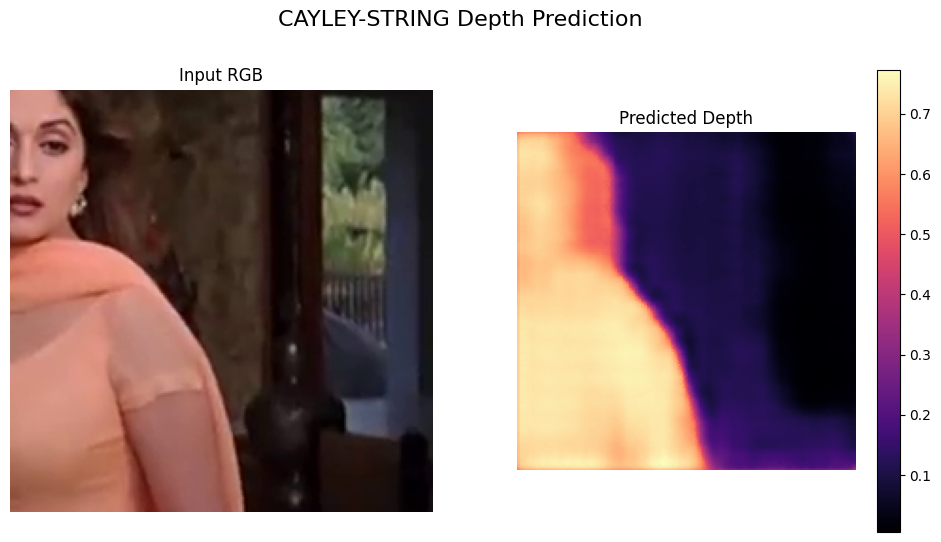

📊 Saved to: outputs/cayley_prediction_4_layers.png
   Depth range: [0.005, 0.773]

TRAINING CIRCULANT-STRING

🚀 Training CIRCULANT-STRING
   4 layers, 192 dim


Training circulant-STRING:  10%|█         | 104/1000 [03:37<00:29, 30.07it/s, loss=0.1827]


[Step 100] Avg Loss: 0.2260


Training circulant-STRING:  21%|██        | 208/1000 [03:40<00:24, 32.24it/s, loss=0.0863]


[Step 200] Avg Loss: 0.1362


...


[Step 800] Avg Loss: 0.0531


Training circulant-STRING:  90%|█████████ | 904/1000 [04:02<00:03, 27.26it/s, loss=0.0536]


[Step 900] Avg Loss: 0.0490


Training circulant-STRING: 100%|██████████| 1000/1000 [04:05<00:00,  4.07it/s, loss=0.0377]



✅ Training complete! Saved to ./checkpoints/circulant_string_4_layers.pkl
   Final loss: 0.0377

🔮 Inference: CIRCULANT-STRING


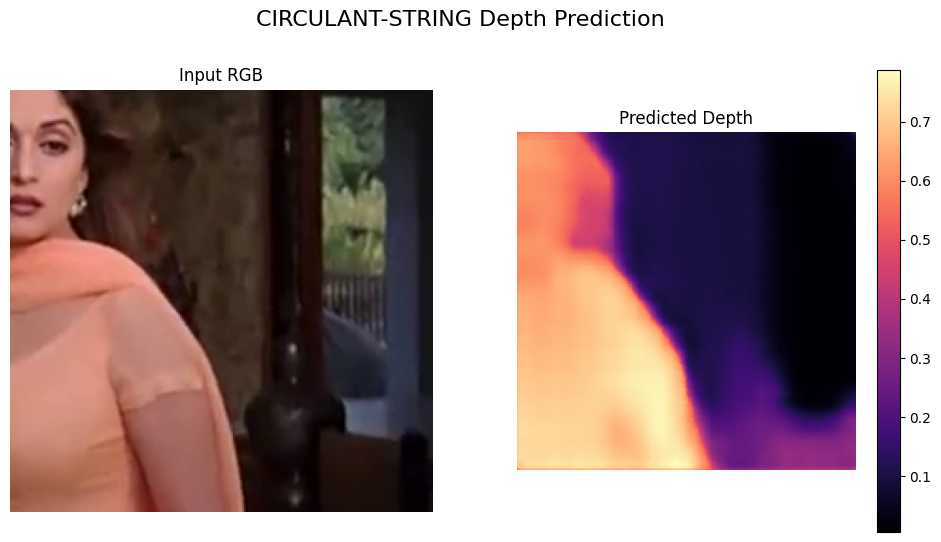

📊 Saved to: outputs/circulant_prediction_4_layers.png
   Depth range: [0.006, 0.787]


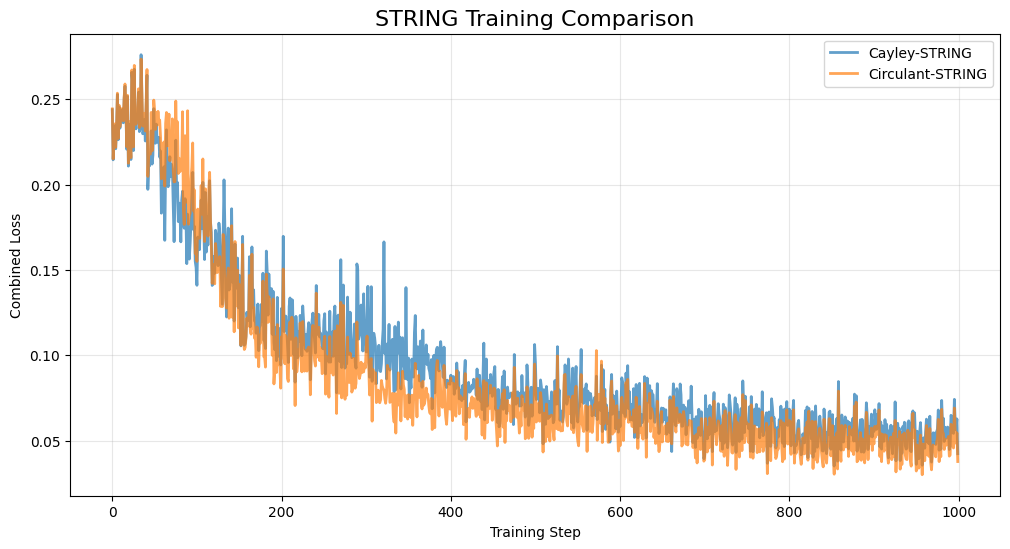

📊 Comparison saved to outputs/string_comparison.png


In [42]:
# @title ### Run Both Methods

# Train Cayley-STRING
print("\n" + "="*60)
print("TRAINING CAYLEY-STRING")
print("="*60)

cayley_config = {
    'seed': 42,
    'data_dir': "./data",
    'batch_size': 8,
    'steps': 1000,  # Reduced for faster testing
    'lr': 3e-4,
    'num_layers': 4,  # Reduced to speed up
    'embed_dim': 192,
    'num_heads': 3,
    'string_type': 'cayley',
    'checkpoint_path': "./checkpoints/cayley_string_4_layers.pkl"
}

cayley_checkpoint, cayley_losses = train_model(cayley_config)
if cayley_checkpoint:
    run_inference(cayley_config, "./data/input_frames/frame_0014.png")

# Train Circulant-STRING
print("\n" + "="*60)
print("TRAINING CIRCULANT-STRING")
print("="*60)

circulant_config = {
    'seed': 42,
    'data_dir': "./data",
    'batch_size': 8,
    'steps': 1000,  # Reduced for faster testing
    'lr': 3e-4,
    'num_layers': 4,  # Reduced to speed up
    'embed_dim': 192,
    'num_heads': 3,
    'string_type': 'circulant',
    'checkpoint_path': "./checkpoints/circulant_string_4_layers.pkl"
}

circulant_checkpoint, circulant_losses = train_model(circulant_config)
if circulant_checkpoint:
    run_inference(circulant_config, "./data/input_frames/frame_0014.png")

# Compare (only if both trained)
if cayley_losses and circulant_losses:
    compare_methods(cayley_losses, circulant_losses)
else:
    print("\n⚠️ Skipping comparison (no training data)")

In [43]:
# @title ### Cell 15: Detailed Single Image Analysis (with Ground Truth)
def detailed_analysis(config: Dict, image_path: str):
    """Comprehensive analysis: input, GT, prediction, errors, metrics."""
    print(f"\n{'='*60}")
    print(f"📊 Detailed Analysis: {config['string_type'].upper()}-STRING")
    print(f"{'='*60}")

    # Load model
    with open(config['checkpoint_path'], 'rb') as f:
        model_state = pickle.load(f)

    rngs = nnx.Rngs(config['seed'])
    model = ViTForDepth_STRING(
        patch_size=16,
        num_layers=config['num_layers'],
        embed_dim=config['embed_dim'],
        num_heads=config['num_heads'],
        rngs=rngs,
        string_type=config['string_type']
    )
    nnx.update(model, model_state)

    # Load image and ground truth
    img = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
    img = img.astype(np.float32) / 255.0

    depth_path = image_path.replace("input_frames", "depth_maps")
    if os.path.exists(depth_path):
        depth_gt = cv2.imread(depth_path, cv2.IMREAD_GRAYSCALE)
        depth_gt = depth_gt.astype(np.float32) / 255.0
    else:
        print("⚠️ Ground truth not found")
        depth_gt = np.zeros_like(img[:, :, 0])

    # Crop to 224x224
    h, w = 224, 224
    y_start = (img.shape[0] - h) // 2
    x_start = (img.shape[1] - w) // 2

    img_cropped = img[y_start:y_start+h, x_start:x_start+w]
    depth_gt_cropped = depth_gt[y_start:y_start+h, x_start:x_start+w]

    # Predict
    @nnx.jit
    def predict(model, img):
        return model(img, train=False)

    depth_pred = predict(model, jnp.expand_dims(img_cropped, 0)).squeeze()

    # Calculate metrics
    mae = np.mean(np.abs(depth_pred - depth_gt_cropped))
    rmse = np.sqrt(np.mean((depth_pred - depth_gt_cropped)**2))

    mask = depth_gt_cropped > 0.01
    if mask.any():
        rel = np.mean(np.abs(depth_pred[mask] - depth_gt_cropped[mask]) / depth_gt_cropped[mask])
    else:
        rel = 0

    corr = np.corrcoef(depth_gt_cropped.flatten(), depth_pred.flatten())[0, 1]

    # Create comprehensive visualization
    fig = plt.figure(figsize=(20, 10))

    # Row 1: Input, GT, Prediction, Error
    ax1 = plt.subplot(2, 4, 1)
    ax1.imshow(img_cropped)
    ax1.set_title("Input RGB\n224×224", fontsize=12, fontweight='bold')
    ax1.axis('off')

    ax2 = plt.subplot(2, 4, 2)
    im2 = ax2.imshow(depth_gt_cropped, cmap='magma', vmin=0, vmax=1)
    ax2.set_title(f"Ground Truth\n[{depth_gt_cropped.min():.3f}, {depth_gt_cropped.max():.3f}]",
                  fontsize=12, fontweight='bold')
    ax2.axis('off')
    plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)

    ax3 = plt.subplot(2, 4, 3)
    im3 = ax3.imshow(depth_pred, cmap='magma', vmin=0, vmax=1)
    ax3.set_title(f"Prediction\n[{depth_pred.min():.3f}, {depth_pred.max():.3f}]",
                  fontsize=12, fontweight='bold')
    ax3.axis('off')
    plt.colorbar(im3, ax=ax3, fraction=0.046, pad=0.04)

    ax4 = plt.subplot(2, 4, 4)
    error_map = np.abs(depth_pred - depth_gt_cropped)
    im4 = ax4.imshow(error_map, cmap='hot', vmin=0, vmax=0.3)
    ax4.set_title(f"Absolute Error\nMean: {error_map.mean():.3f}",
                  fontsize=12, fontweight='bold')
    ax4.axis('off')
    plt.colorbar(im4, ax=ax4, fraction=0.046, pad=0.04)

    # Row 2: Histogram, Cross-section, Scatter, Metrics
    ax5 = plt.subplot(2, 4, 5)
    ax5.hist(depth_gt_cropped.flatten(), bins=50, alpha=0.5, label='GT', color='blue')
    ax5.hist(depth_pred.flatten(), bins=50, alpha=0.5, label='Pred', color='red')
    ax5.set_xlabel('Depth Value')
    ax5.set_ylabel('Frequency')
    ax5.set_title('Depth Distribution', fontsize=12, fontweight='bold')
    ax5.legend()
    ax5.grid(True, alpha=0.3)

    ax6 = plt.subplot(2, 4, 6)
    mid_row = h // 2
    ax6.plot(depth_gt_cropped[mid_row, :], label='GT', linewidth=2, color='blue')
    ax6.plot(depth_pred[mid_row, :], label='Pred', linewidth=2, color='red', linestyle='--')
    ax6.set_xlabel('Pixel Position (x)')
    ax6.set_ylabel('Depth')
    ax6.set_title(f'Horizontal Slice (y={mid_row})', fontsize=12, fontweight='bold')
    ax6.legend()
    ax6.grid(True, alpha=0.3)

    ax7 = plt.subplot(2, 4, 7)
    sample_idx = np.random.choice(depth_gt_cropped.size, 5000, replace=False)
    gt_sample = depth_gt_cropped.flatten()[sample_idx]
    pred_sample = depth_pred.flatten()[sample_idx]
    ax7.scatter(gt_sample, pred_sample, alpha=0.3, s=1)
    ax7.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Perfect')
    ax7.set_xlabel('Ground Truth')
    ax7.set_ylabel('Predicted')
    ax7.set_title('GT vs Prediction', fontsize=12, fontweight='bold')
    ax7.legend()
    ax7.grid(True, alpha=0.3)
    ax7.set_xlim([0, 1])
    ax7.set_ylim([0, 1])

    ax8 = plt.subplot(2, 4, 8)
    ax8.axis('off')
    metrics_text = f"""
    Performance Metrics:

    MAE:  {mae:.4f}
    RMSE: {rmse:.4f}
    Rel:  {rel:.4f}

    Error Stats:
    Min:  {error_map.min():.4f}
    Max:  {error_map.max():.4f}
    Std:  {error_map.std():.4f}

    Correlation: {corr:.4f}
    """
    ax8.text(0.1, 0.5, metrics_text, fontsize=11, family='monospace',
             verticalalignment='center',
             bbox=dict(boxstyle="round", facecolor='wheat', alpha=0.5))

    plt.suptitle(f"{config['string_type'].upper()}-STRING ({config['num_layers']}-Layer): Detailed Analysis",
                 fontsize=16, fontweight='bold')
    plt.tight_layout()

    os.makedirs("outputs", exist_ok=True)
    output_path = f"outputs/detailed_{config['string_type']}_{config['num_layers']}L.png"
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.show()

    print(f"\n📊 Saved to: {output_path}")
    print(f"\n📈 Metrics:")
    print(f"   MAE:  {mae:.4f}")
    print(f"   RMSE: {rmse:.4f}")
    print(f"   Rel:  {rel:.4f}")
    print(f"   Corr: {corr:.4f}")

print("✅ Detailed analysis ready")

✅ Detailed analysis ready


In [44]:
# @title ### Cell 16: Multi-Resolution Testing
def test_multi_resolution(config: Dict, image_path: str):
    """Test model at multiple resolutions with ground truth."""
    print(f"\n{'='*60}")
    print(f"🎯 Multi-Resolution Test: {config['string_type'].upper()}-STRING")
    print(f"{'='*60}")

    # Load model
    with open(config['checkpoint_path'], 'rb') as f:
        model_state = pickle.load(f)

    rngs = nnx.Rngs(config['seed'])
    model = ViTForDepth_STRING(
        patch_size=16,
        num_layers=config['num_layers'],
        embed_dim=config['embed_dim'],
        num_heads=config['num_heads'],
        rngs=rngs,
        string_type=config['string_type']
    )
    nnx.update(model, model_state)

    # Load data
    img_original = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
    img_original = img_original.astype(np.float32) / 255.0

    depth_path = image_path.replace("input_frames", "depth_maps")
    if os.path.exists(depth_path):
        depth_gt = cv2.imread(depth_path, cv2.IMREAD_GRAYSCALE)
        depth_gt = depth_gt.astype(np.float32) / 255.0
    else:
        depth_gt = np.zeros_like(img_original[:, :, 0])

    # Test at multiple sizes
    test_sizes = [
        (224, 224),   # Training size
        (160, 160),   # Smaller
        (320, 320),   # Larger
        (224, 336),   # Different aspect
    ]

    @nnx.jit
    def predict(model, img):
        return model(img, train=False)

    # Create visualization
    fig = plt.figure(figsize=(20, 12))

    for idx, (h, w) in enumerate(test_sizes):
        # Resize
        img_resized = cv2.resize(img_original, (w, h))
        depth_gt_resized = cv2.resize(depth_gt, (w, h))

        # Predict
        depth_pred = predict(model, jnp.expand_dims(img_resized, 0)).squeeze()

        # Metrics
        mae = np.mean(np.abs(depth_pred - depth_gt_resized))
        rmse = np.sqrt(np.mean((depth_pred - depth_gt_resized)**2))

        # Plot row: RGB, GT, Pred, Error
        ax1 = plt.subplot(len(test_sizes), 4, idx * 4 + 1)
        ax1.imshow(img_resized)
        ax1.set_title(f"Input {h}×{w}", fontsize=11, fontweight='bold')
        ax1.axis('off')

        ax2 = plt.subplot(len(test_sizes), 4, idx * 4 + 2)
        ax2.imshow(depth_gt_resized, cmap='magma', vmin=0, vmax=1)
        ax2.set_title("Ground Truth", fontsize=11, fontweight='bold')
        ax2.axis('off')

        ax3 = plt.subplot(len(test_sizes), 4, idx * 4 + 3)
        ax3.imshow(depth_pred, cmap='magma', vmin=0, vmax=1)
        ax3.set_title(f"Pred (MAE: {mae:.3f})", fontsize=11, fontweight='bold')
        ax3.axis('off')

        ax4 = plt.subplot(len(test_sizes), 4, idx * 4 + 4)
        error = np.abs(depth_pred - depth_gt_resized)
        im = ax4.imshow(error, cmap='hot', vmin=0, vmax=0.3)
        ax4.set_title(f"Error (RMSE: {rmse:.3f})", fontsize=11, fontweight='bold')
        ax4.axis('off')
        plt.colorbar(im, ax=ax4, fraction=0.046, pad=0.04)

        print(f"✓ {h}×{w}: MAE={mae:.4f}, RMSE={rmse:.4f}")

    plt.suptitle(f"{config['string_type'].upper()}-STRING: Multi-Resolution Performance",
                 fontsize=14, fontweight='bold')
    plt.tight_layout()

    output_path = f"outputs/multires_{config['string_type']}_{config['num_layers']}L.png"
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.show()

    print(f"\n📊 Saved to: {output_path}")

print("✅ Multi-resolution testing ready")

✅ Multi-resolution testing ready


In [45]:
# @title ### Cell 17: Training Curve Comparison (Multiple Models)
def plot_training_curves(results: Dict[str, List[float]]):
    """Plot training loss for multiple models."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#F38181', '#AA96DA']

    # Raw losses
    for (name, losses), color in zip(results.items(), colors):
        ax1.plot(losses, label=name, linewidth=1.5, alpha=0.7, color=color)

    ax1.set_title("Training Loss (Raw)", fontsize=14, fontweight='bold')
    ax1.set_xlabel("Step")
    ax1.set_ylabel("Combined Loss")
    ax1.legend(loc='best')
    ax1.grid(True, alpha=0.3)

    # Smoothed losses
    for (name, losses), color in zip(results.items(), colors):
        if len(losses) > 50:
            window = 50
            smoothed = np.convolve(losses, np.ones(window)/window, mode='valid')
            x = np.arange(window//2, len(losses) - window//2 + 1)
            ax2.plot(x, smoothed, label=name, linewidth=2.5, color=color)
        else:
            ax2.plot(losses, label=name, linewidth=2.5, color=color)

    ax2.set_title("Training Loss (Smoothed)", fontsize=14, fontweight='bold')
    ax2.set_xlabel("Step")
    ax2.set_ylabel("Combined Loss")
    ax2.legend(loc='best')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("outputs/training_comparison.png", dpi=150, bbox_inches='tight')
    plt.show()

    print("📊 Training comparison saved to outputs/training_comparison.png")

    # Print final statistics
    print("\n📈 Final Loss Statistics:")
    for name, losses in results.items():
        final_100 = np.mean(losses[-100:]) if len(losses) >= 100 else np.mean(losses)
        print(f"   {name}: {final_100:.4f}")

print("✅ Training curve comparison ready")

✅ Training curve comparison ready


In [46]:
# @title ### Cell 18: Extreme Resolution Stress Test
def test_extreme_resolutions(config: Dict, image_path: str):
    """Test model robustness at extreme resolutions."""
    print(f"\n{'='*60}")
    print(f"🔬 Extreme Resolution Test: {config['string_type'].upper()}-STRING")
    print(f"{'='*60}")

    # Load model
    with open(config['checkpoint_path'], 'rb') as f:
        model_state = pickle.load(f)

    rngs = nnx.Rngs(config['seed'])
    model = ViTForDepth_STRING(
        patch_size=16,
        num_layers=config['num_layers'],
        embed_dim=config['embed_dim'],
        num_heads=config['num_heads'],
        rngs=rngs,
        string_type=config['string_type']
    )
    nnx.update(model, model_state)

    # Load image
    img = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
    img = img.astype(np.float32) / 255.0

    # Test extreme cases
    extreme_sizes = [
        (96, 96),     # Very small
        (512, 512),   # Large
        (128, 384),   # 1:3 aspect ratio
        (384, 128),   # 3:1 aspect ratio
    ]

    results = []
    for h, w in extreme_sizes:
        try:
            img_resized = cv2.resize(img, (w, h))
            img_batch = jnp.expand_dims(img_resized, 0)

            import time
            start = time.time()
            depth_pred = model(img_batch, train=False)
            elapsed = time.time() - start

            results.append({
                'size': (h, w),
                'time': elapsed,
                'output_shape': depth_pred.shape,
                'success': True,
                'depth_range': (float(depth_pred.min()), float(depth_pred.max()))
            })

            print(f"✓ {h}×{w}: {elapsed:.3f}s, range=[{depth_pred.min():.3f}, {depth_pred.max():.3f}]")

        except Exception as e:
            results.append({
                'size': (h, w),
                'success': False,
                'error': str(e)
            })
            print(f"✗ {h}×{w}: Failed - {e}")

    # Summary table
    print(f"\n📊 Summary:")
    print(f"{'Size':<12} {'Time (s)':<10} {'Status':<10} {'Output Shape'}")
    print("-" * 60)
    for r in results:
        if r['success']:
            print(f"{r['size'][0]}×{r['size'][1]:<8} {r['time']:<10.3f} {'OK':<10} {r['output_shape']}")
        else:
            print(f"{r['size'][0]}×{r['size'][1]:<8} {'-':<10} {'FAILED':<10} -")

print("✅ Extreme resolution testing ready")

✅ Extreme resolution testing ready


✅ Complete analysis pipeline ready

To run full analysis: run_complete_analysis()

                              CAYLEY-STRING

🚀 Training CAYLEY-STRING
   6 layers, 192 dim


Training cayley-STRING:   5%|▌         | 105/2000 [03:30<01:05, 29.04it/s, loss=0.2160]


[Step 100] Avg Loss: 0.2349


Training cayley-STRING:  10%|█         | 205/2000 [03:34<01:02, 28.91it/s, loss=0.1078]


[Step 200] Avg Loss: 0.1592


...


[Step 1800] Avg Loss: 0.0381


Training circulant-STRING:  95%|█████████▌| 1907/2000 [04:37<00:02, 31.71it/s, loss=0.0367]


[Step 1900] Avg Loss: 0.0379


Training circulant-STRING: 100%|██████████| 2000/2000 [04:40<00:00,  7.14it/s, loss=0.0395]



✅ Training complete! Saved to ./checkpoints/circulant_string_6L.pkl
   Final loss: 0.0395

                         DETAILED ANALYSIS

📊 Detailed Analysis: CAYLEY-STRING


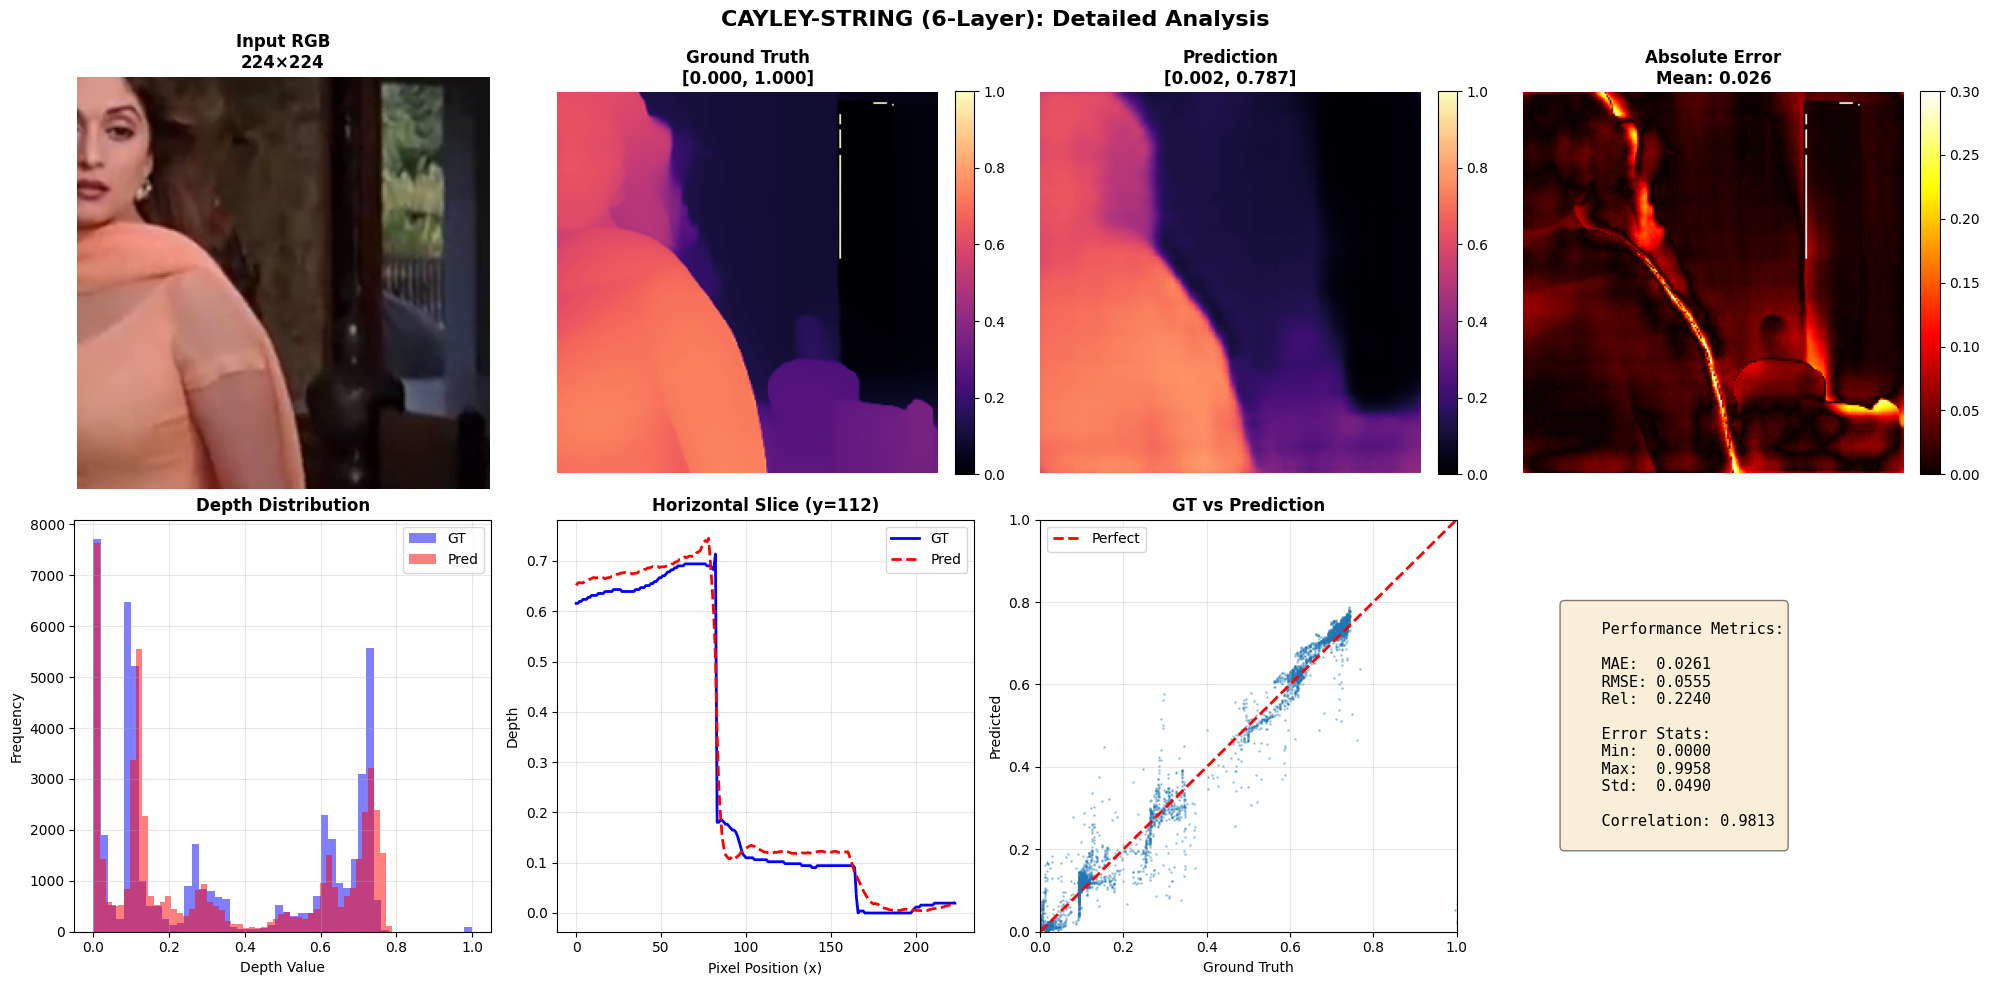


📊 Saved to: outputs/detailed_cayley_6L.png

📈 Metrics:
   MAE:  0.0261
   RMSE: 0.0555
   Rel:  0.2240
   Corr: 0.9813

📊 Detailed Analysis: CIRCULANT-STRING


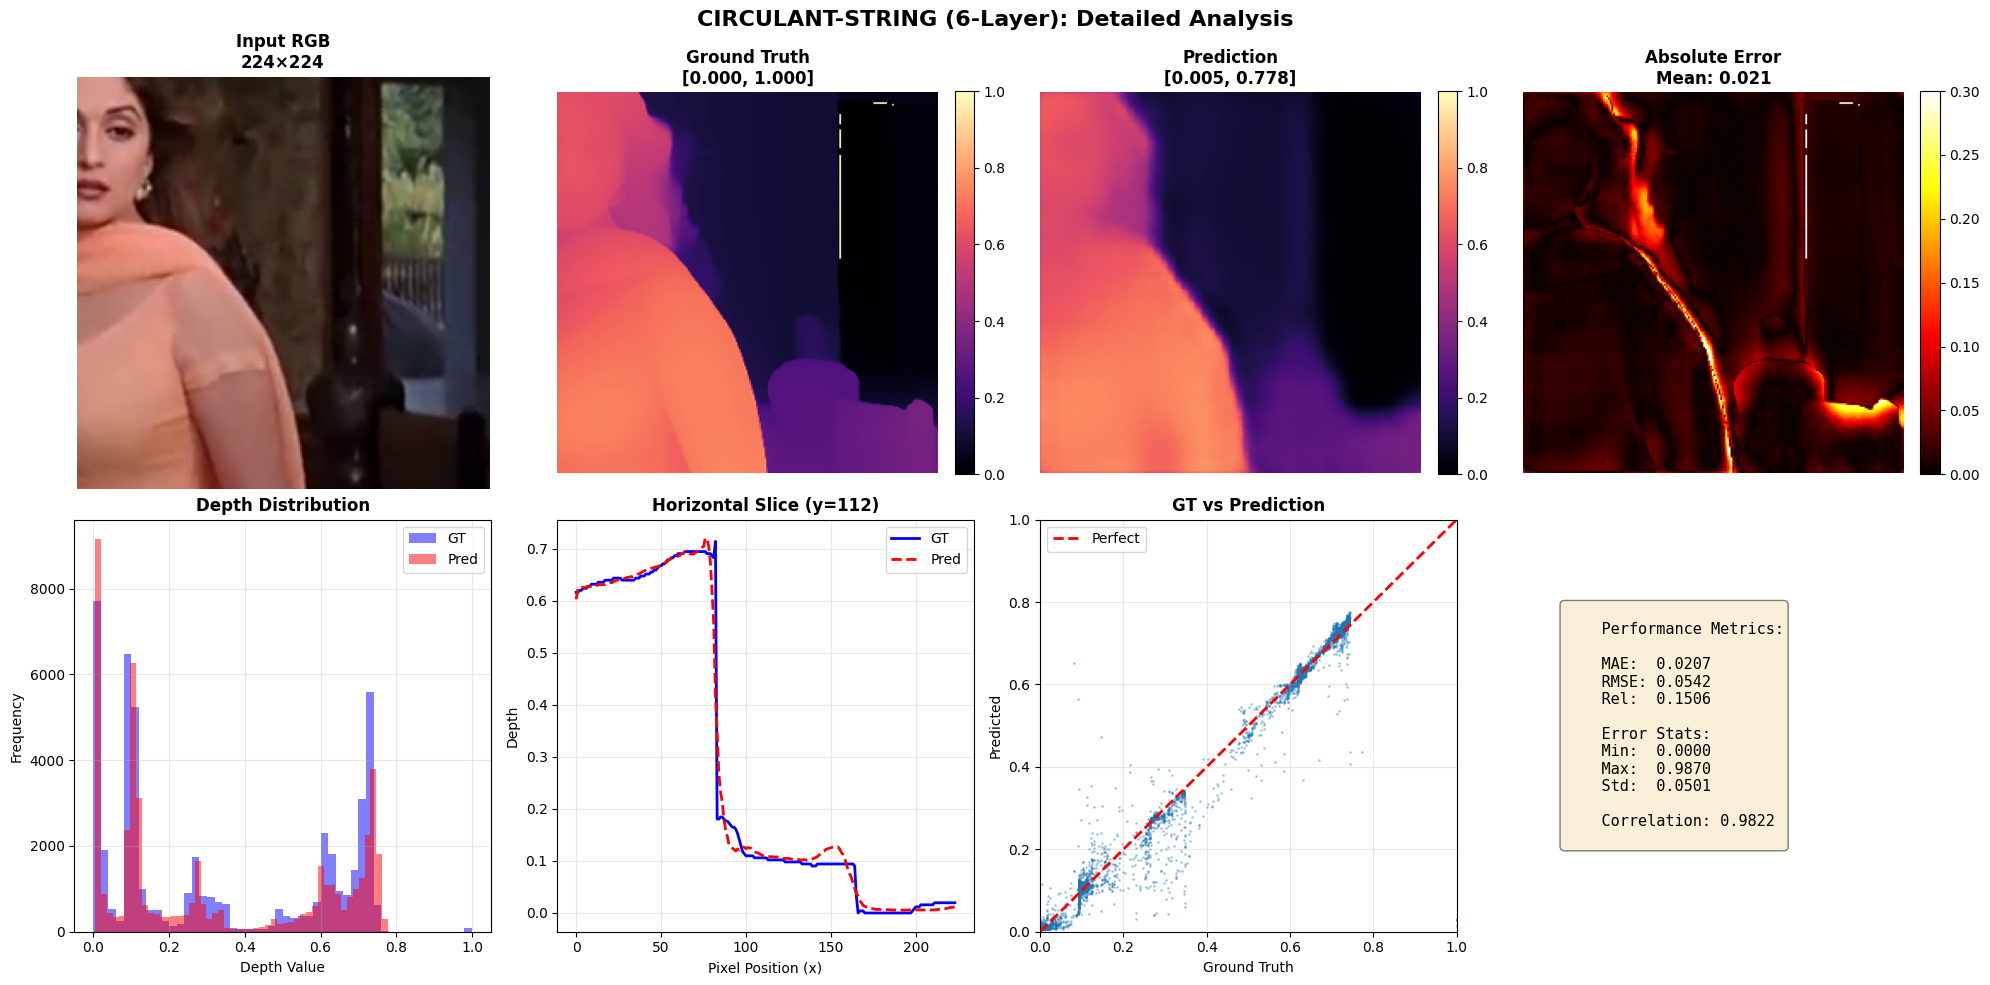


📊 Saved to: outputs/detailed_circulant_6L.png

📈 Metrics:
   MAE:  0.0207
   RMSE: 0.0542
   Rel:  0.1506
   Corr: 0.9822

                      MULTI-RESOLUTION TESTING

🎯 Multi-Resolution Test: CAYLEY-STRING
✓ 224×224: MAE=0.2871, RMSE=0.3409
✓ 160×160: MAE=0.2855, RMSE=0.3369
✓ 320×320: MAE=0.3096, RMSE=0.3667
✓ 224×336: MAE=0.2936, RMSE=0.3510


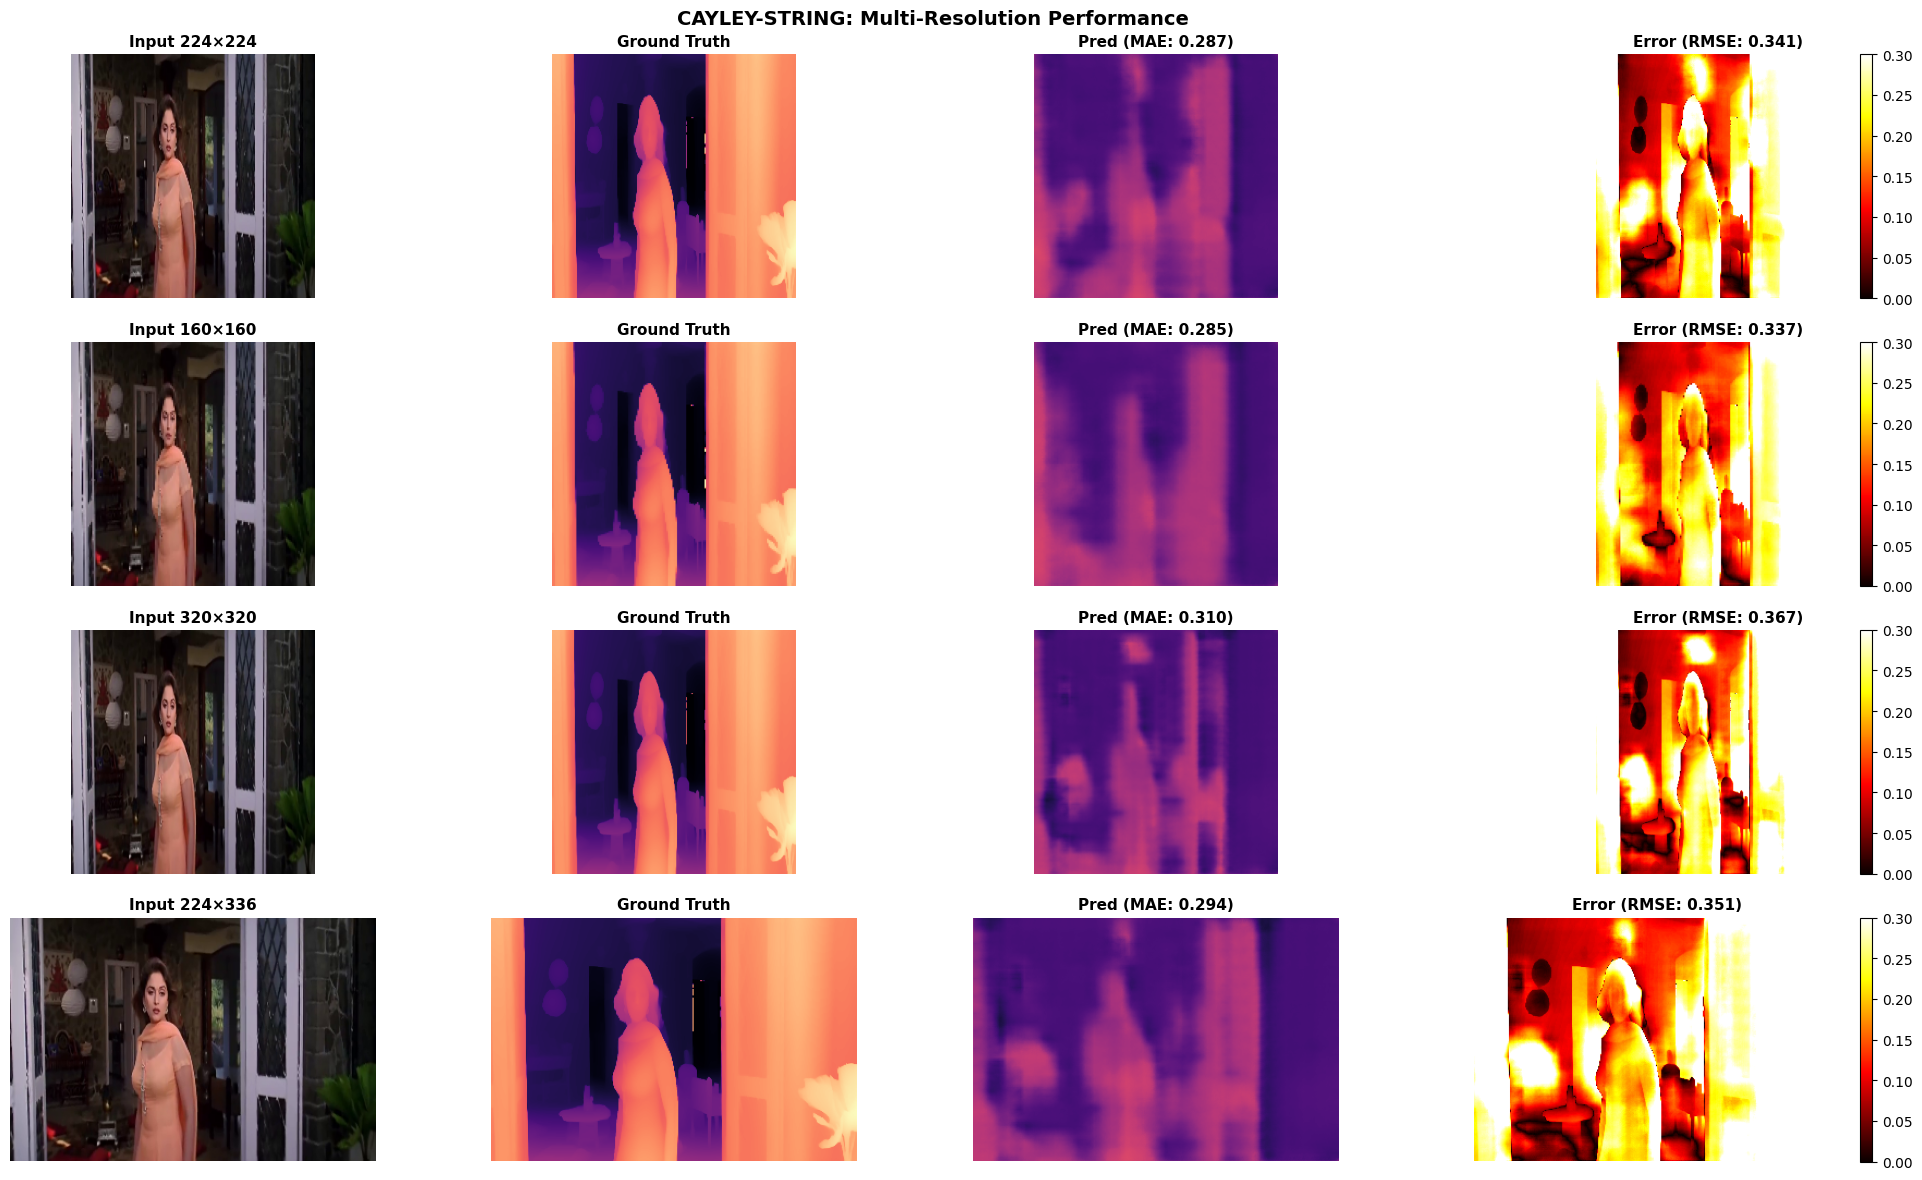


📊 Saved to: outputs/multires_cayley_6L.png

🎯 Multi-Resolution Test: CIRCULANT-STRING
✓ 224×224: MAE=0.3265, RMSE=0.3966
✓ 160×160: MAE=0.3324, RMSE=0.3999
✓ 320×320: MAE=0.3285, RMSE=0.3997
✓ 224×336: MAE=0.3268, RMSE=0.4004


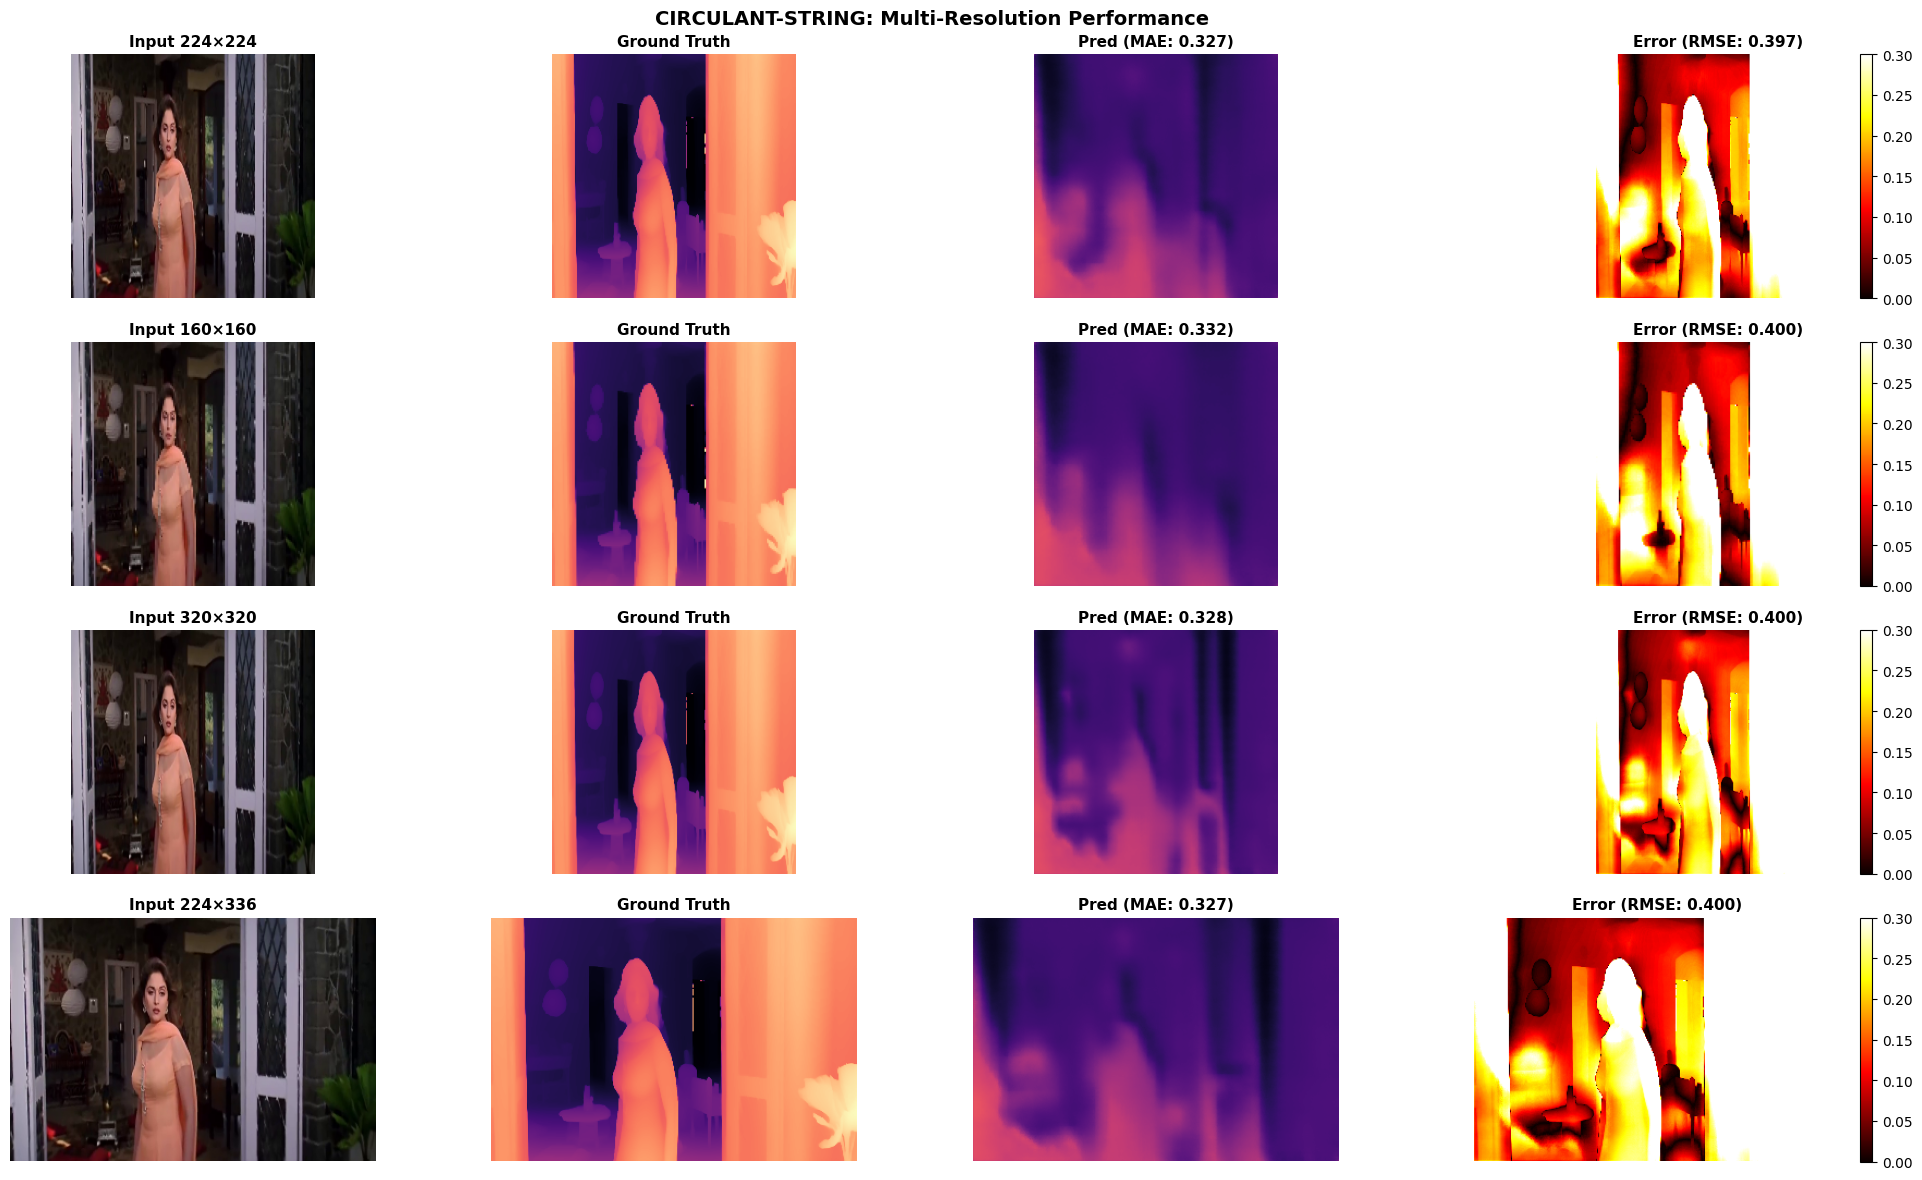


📊 Saved to: outputs/multires_circulant_6L.png

                    EXTREME RESOLUTION TESTING

🔬 Extreme Resolution Test: CAYLEY-STRING
✓ 96×96: 0.129s, range=[0.085, 0.621]
✓ 512×512: 0.130s, range=[0.087, 0.593]
✓ 128×384: 0.127s, range=[0.106, 0.637]
✓ 384×128: 0.131s, range=[0.128, 0.647]

📊 Summary:
Size         Time (s)   Status     Output Shape
------------------------------------------------------------
96×96       0.129      OK         (1, 96, 96, 1)
512×512      0.130      OK         (1, 512, 512, 1)
128×384      0.127      OK         (1, 128, 384, 1)
384×128      0.131      OK         (1, 384, 128, 1)

🔬 Extreme Resolution Test: CIRCULANT-STRING
✓ 96×96: 0.192s, range=[0.060, 0.559]
✓ 512×512: 0.143s, range=[0.061, 0.641]
✓ 128×384: 0.158s, range=[0.053, 0.601]
✓ 384×128: 0.167s, range=[0.054, 0.601]

📊 Summary:
Size         Time (s)   Status     Output Shape
------------------------------------------------------------
96×96       0.192      OK         (1, 96, 96, 1)
512×51

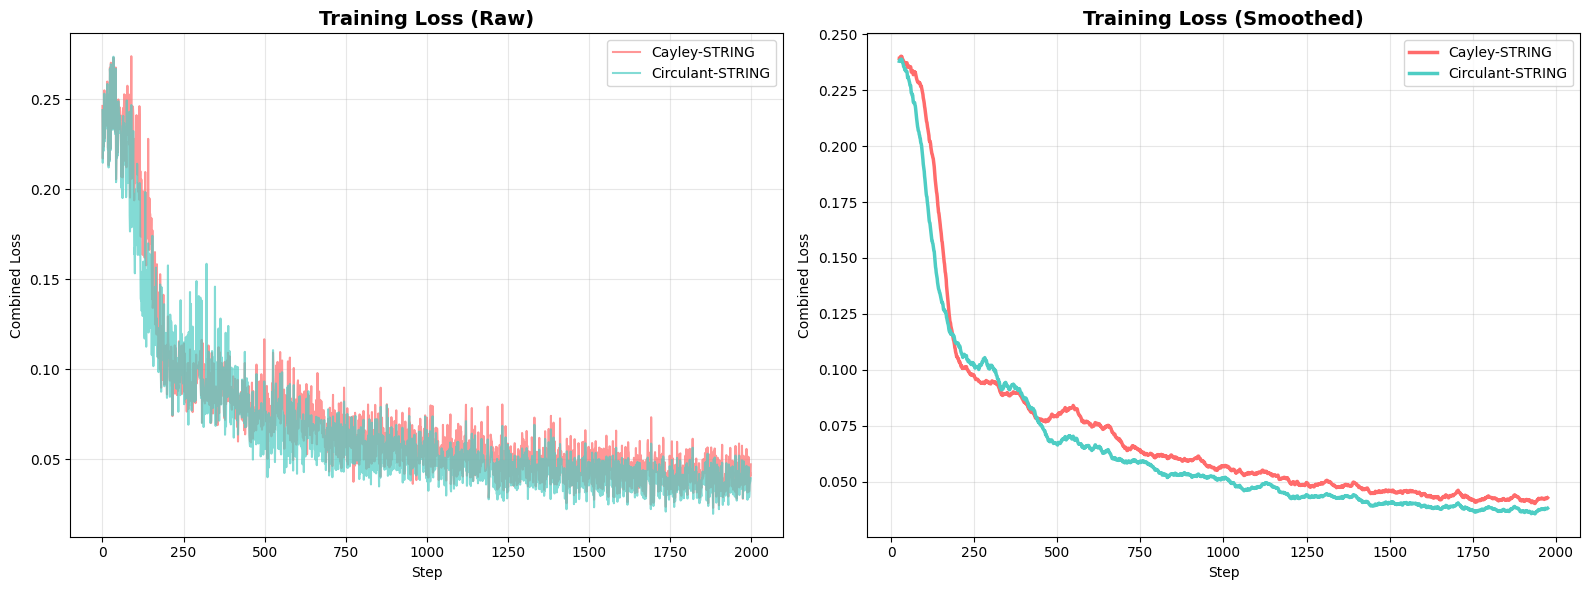

📊 Training comparison saved to outputs/training_comparison.png

📈 Final Loss Statistics:
   Cayley-STRING: 0.0419
   Circulant-STRING: 0.0371

                            ✨ ANALYSIS COMPLETE ✨

All outputs saved to ./outputs/
All checkpoints saved to ./checkpoints/


In [47]:
# @title ### Cell 19: Complete Pipeline with All Analysis

def run_complete_analysis():
    """Run full training and analysis pipeline."""

    # Train both models
    print("\n" + "="*80)
    print(" "*30 + "CAYLEY-STRING")
    print("="*80)

    cayley_config = {
        'seed': 42,
        'data_dir': "./data",
        'batch_size': 8,
        'steps': 2000,
        'lr': 3e-4,
        'num_layers': 6,
        'embed_dim': 192,
        'num_heads': 3,
        'string_type': 'cayley',
        'checkpoint_path': "./checkpoints/cayley_string_6L.pkl"
    }

    cayley_ckpt, cayley_losses = train_model(cayley_config)

    print("\n" + "="*80)
    print(" "*28 + "CIRCULANT-STRING")
    print("="*80)

    circulant_config = {
        'seed': 42,
        'data_dir': "./data",
        'batch_size': 8,
        'steps': 2000,
        'lr': 3e-4,
        'num_layers': 6,
        'embed_dim': 192,
        'num_heads': 3,
        'string_type': 'circulant',
        'checkpoint_path': "./checkpoints/circulant_string_6L.pkl"
    }

    circulant_ckpt, circulant_losses = train_model(circulant_config)

    if not cayley_ckpt or not circulant_ckpt:
        print("\n❌ Training failed, skipping analysis")
        return

    test_image = "./data/input_frames/frame_0014.png"

    # Analysis for both models
    print("\n" + "="*80)
    print(" "*25 + "DETAILED ANALYSIS")
    print("="*80)

    detailed_analysis(cayley_config, test_image)
    detailed_analysis(circulant_config, test_image)

    # Multi-resolution testing
    print("\n" + "="*80)
    print(" "*22 + "MULTI-RESOLUTION TESTING")
    print("="*80)

    test_multi_resolution(cayley_config, test_image)
    test_multi_resolution(circulant_config, test_image)

    # Extreme resolution testing
    print("\n" + "="*80)
    print(" "*20 + "EXTREME RESOLUTION TESTING")
    print("="*80)

    test_extreme_resolutions(cayley_config, test_image)
    test_extreme_resolutions(circulant_config, test_image)

    # Training comparison
    print("\n" + "="*80)
    print(" "*23 + "TRAINING COMPARISON")
    print("="*80)

    plot_training_curves({
        'Cayley-STRING': cayley_losses,
        'Circulant-STRING': circulant_losses
    })

    print("\n" + "="*80)
    print(" "*28 + "✨ ANALYSIS COMPLETE ✨")
    print("="*80)
    print("\nAll outputs saved to ./outputs/")
    print("All checkpoints saved to ./checkpoints/")

print("✅ Complete analysis pipeline ready")
print("\nTo run full analysis: run_complete_analysis()")

# Quick test with all analysis
run_complete_analysis()


📊 Detailed Analysis: CAYLEY-STRING


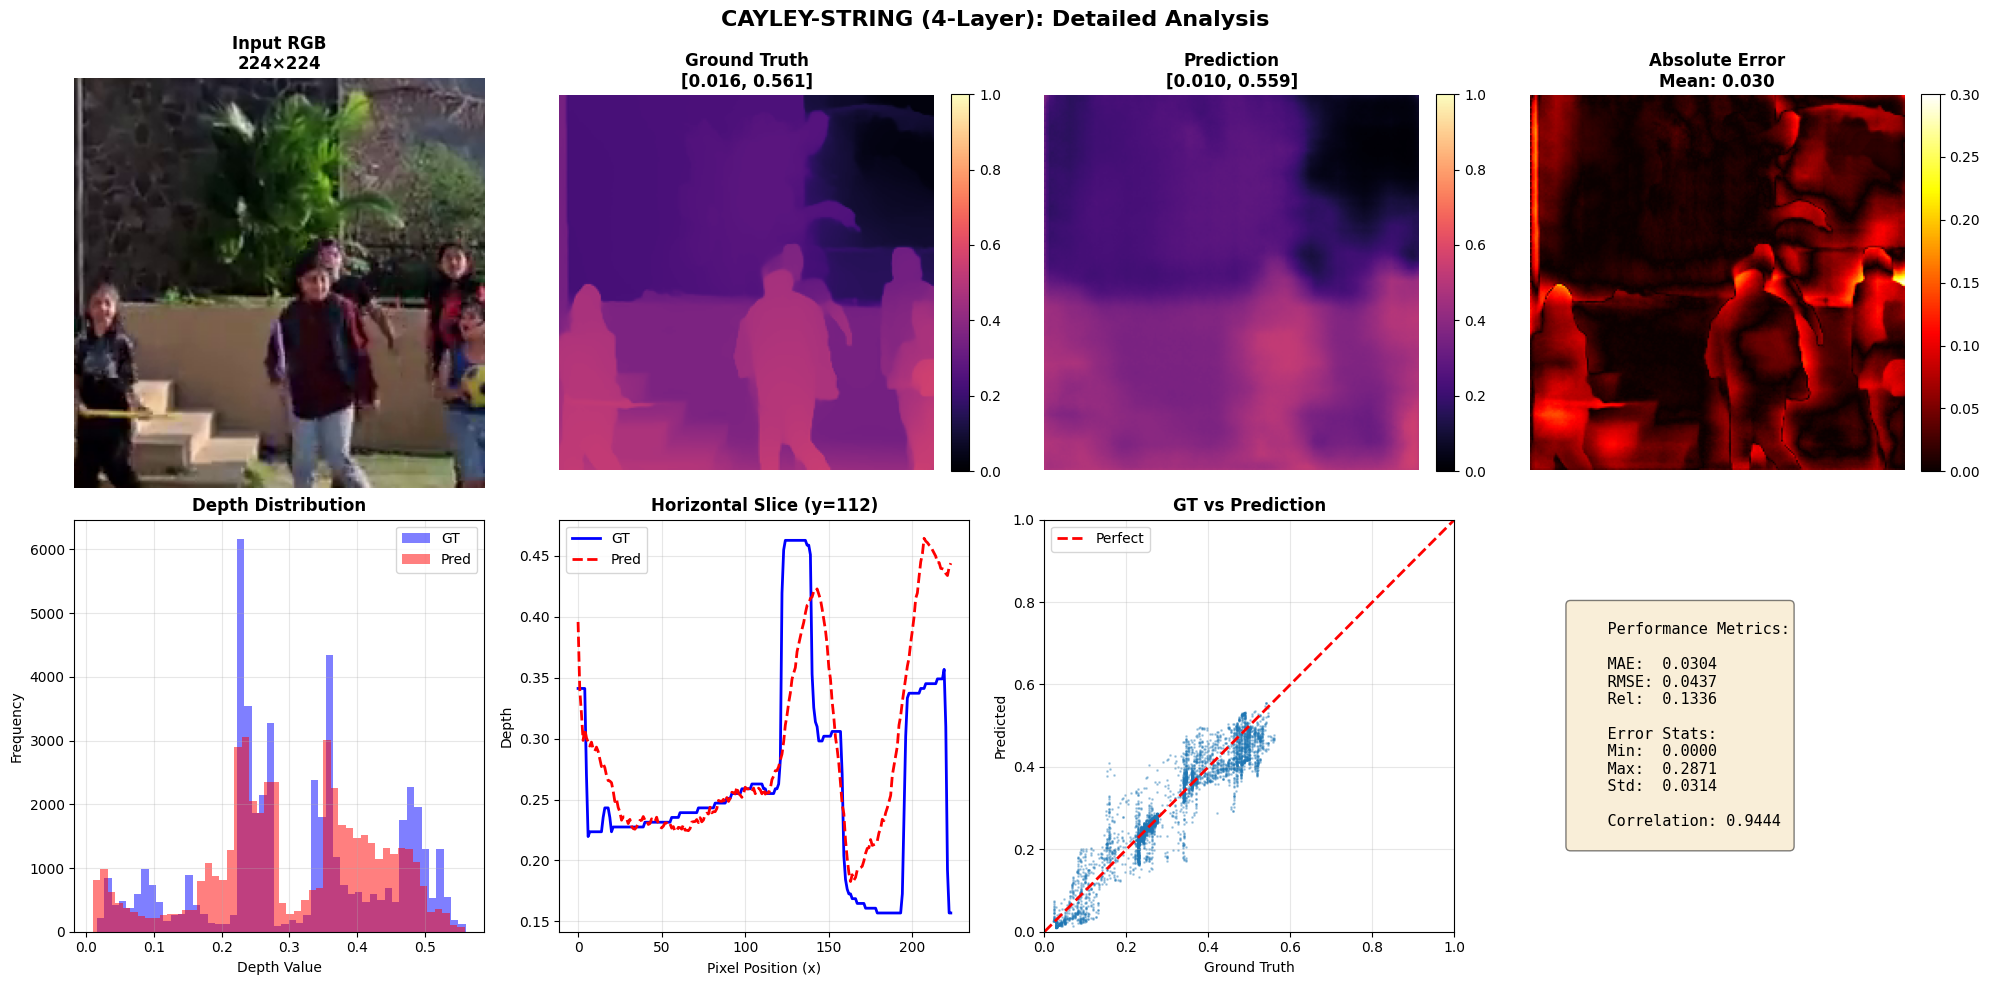


📊 Saved to: outputs/detailed_cayley_4L.png

📈 Metrics:
   MAE:  0.0304
   RMSE: 0.0437
   Rel:  0.1336
   Corr: 0.9444

🎯 Multi-Resolution Test: CAYLEY-STRING
✓ 224×224: MAE=0.2469, RMSE=0.3309
✓ 160×160: MAE=0.2640, RMSE=0.3480
✓ 320×320: MAE=0.2344, RMSE=0.3277
✓ 224×336: MAE=0.2534, RMSE=0.3413


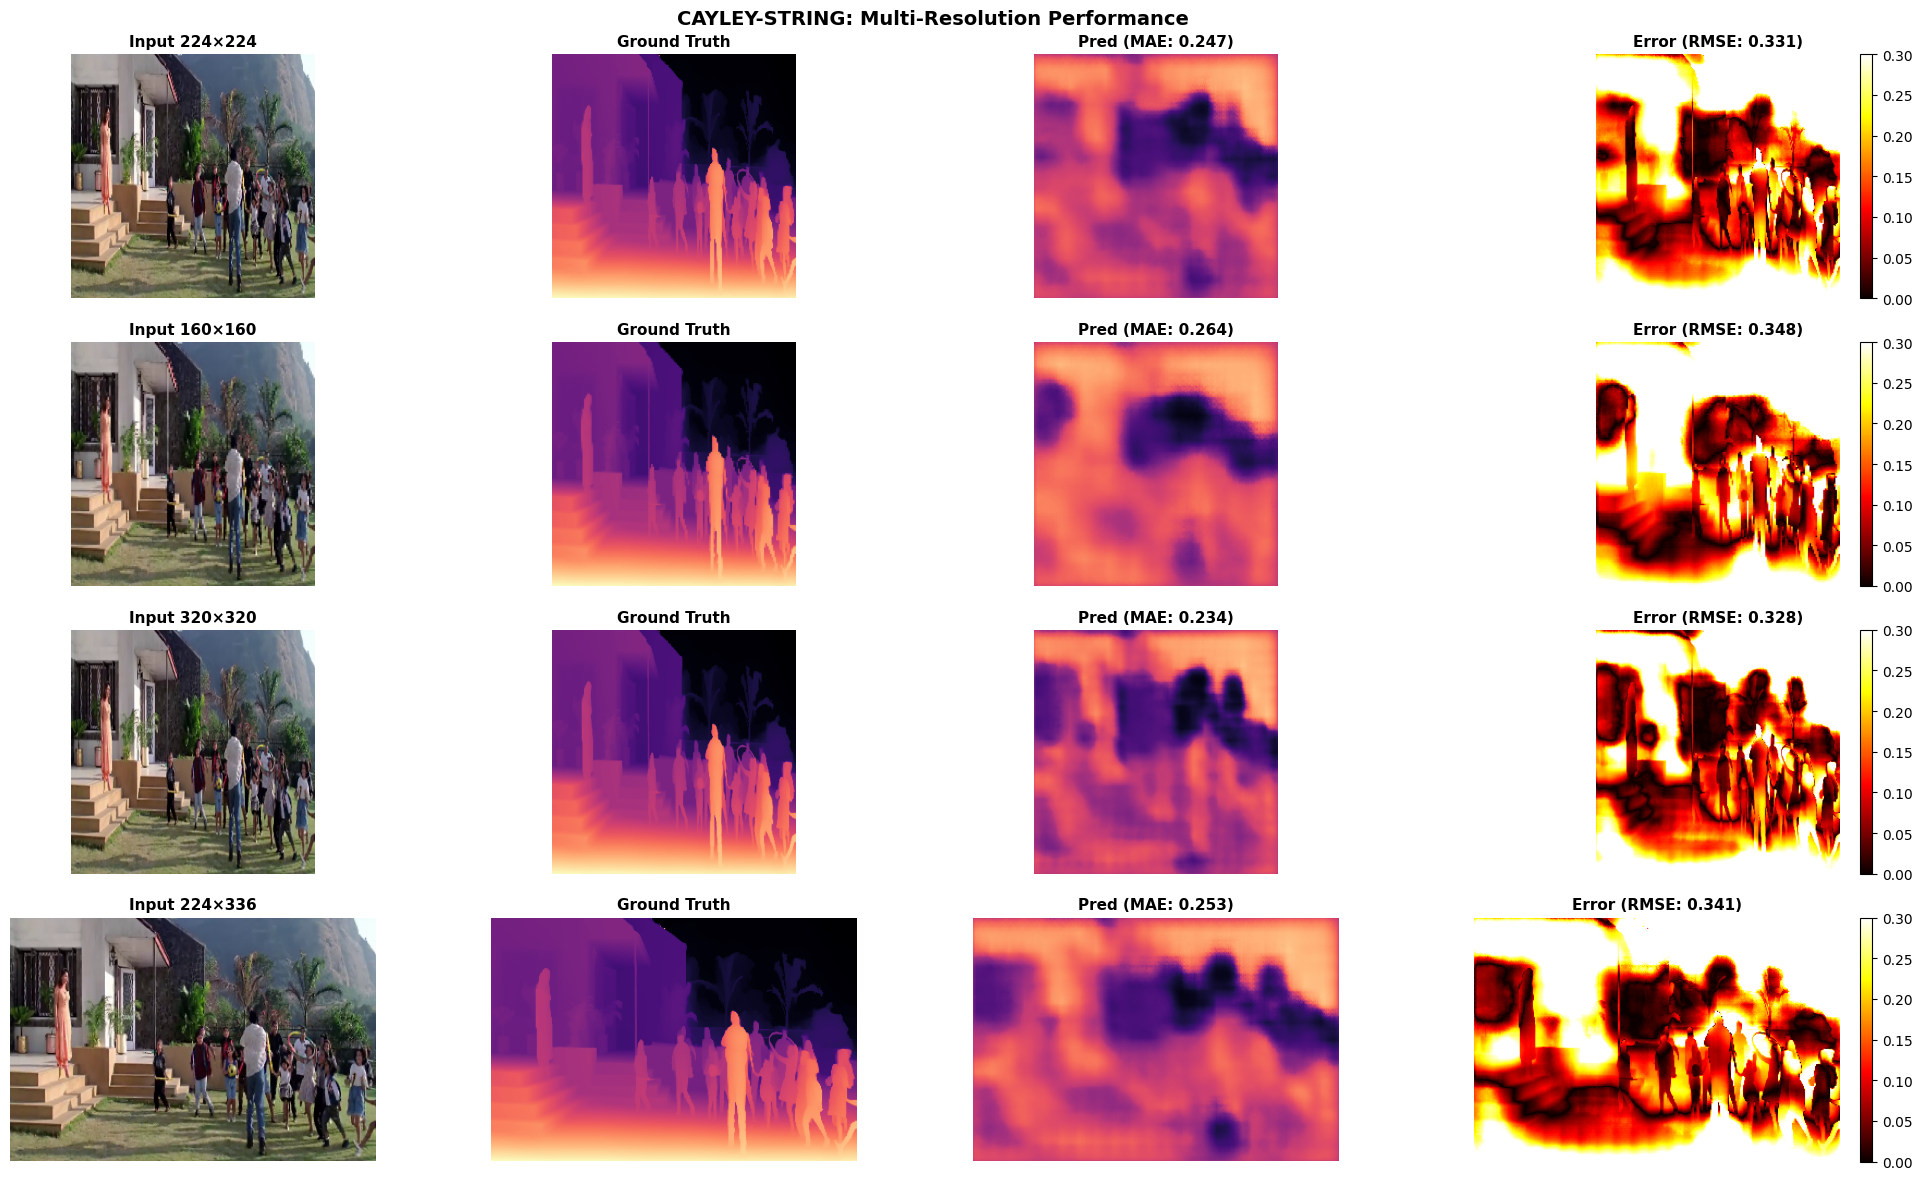


📊 Saved to: outputs/multires_cayley_4L.png

🔬 Extreme Resolution Test: CAYLEY-STRING
✓ 96×96: 0.107s, range=[0.021, 0.856]
✓ 512×512: 0.104s, range=[0.018, 0.852]
✓ 128×384: 0.103s, range=[0.025, 0.860]
✓ 384×128: 0.101s, range=[0.052, 0.858]

📊 Summary:
Size         Time (s)   Status     Output Shape
------------------------------------------------------------
96×96       0.107      OK         (1, 96, 96, 1)
512×512      0.104      OK         (1, 512, 512, 1)
128×384      0.103      OK         (1, 128, 384, 1)
384×128      0.101      OK         (1, 384, 128, 1)


In [48]:
# After training a model
detailed_analysis(cayley_config, "./data/input_frames/frame_0200.png")
test_multi_resolution(cayley_config, "./data/input_frames/frame_0200.png")
test_extreme_resolutions(cayley_config, "./data/input_frames/frame_0200.png")


📊 Detailed Analysis: CAYLEY-STRING
⚠️ Ground truth not found


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning:

invalid value encountered in divide

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning:

invalid value encountered in divide



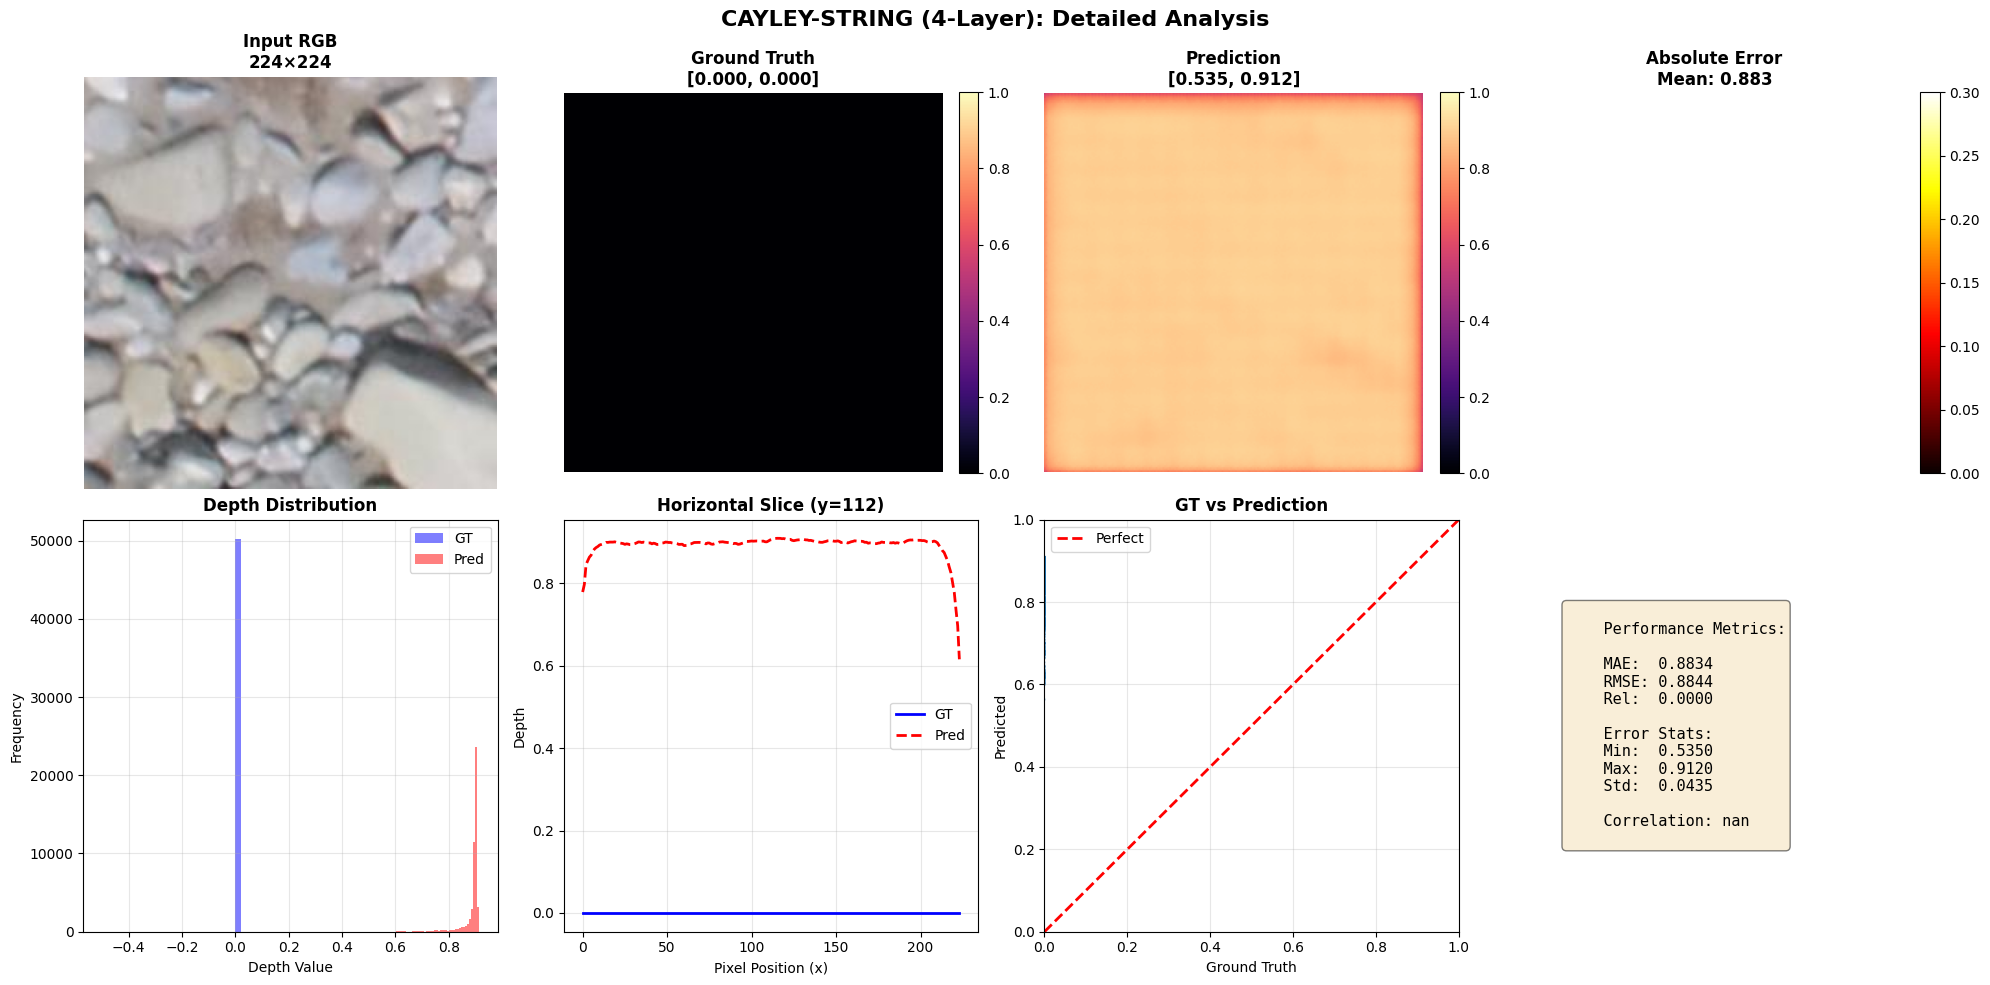


📊 Saved to: outputs/detailed_cayley_4L.png

📈 Metrics:
   MAE:  0.8834
   RMSE: 0.8844
   Rel:  0.0000
   Corr: nan

🎯 Multi-Resolution Test: CAYLEY-STRING
✓ 224×224: MAE=0.8834, RMSE=0.8844
✓ 160×160: MAE=0.8786, RMSE=0.8801
✓ 320×320: MAE=0.8876, RMSE=0.8884
✓ 224×336: MAE=0.8862, RMSE=0.8872


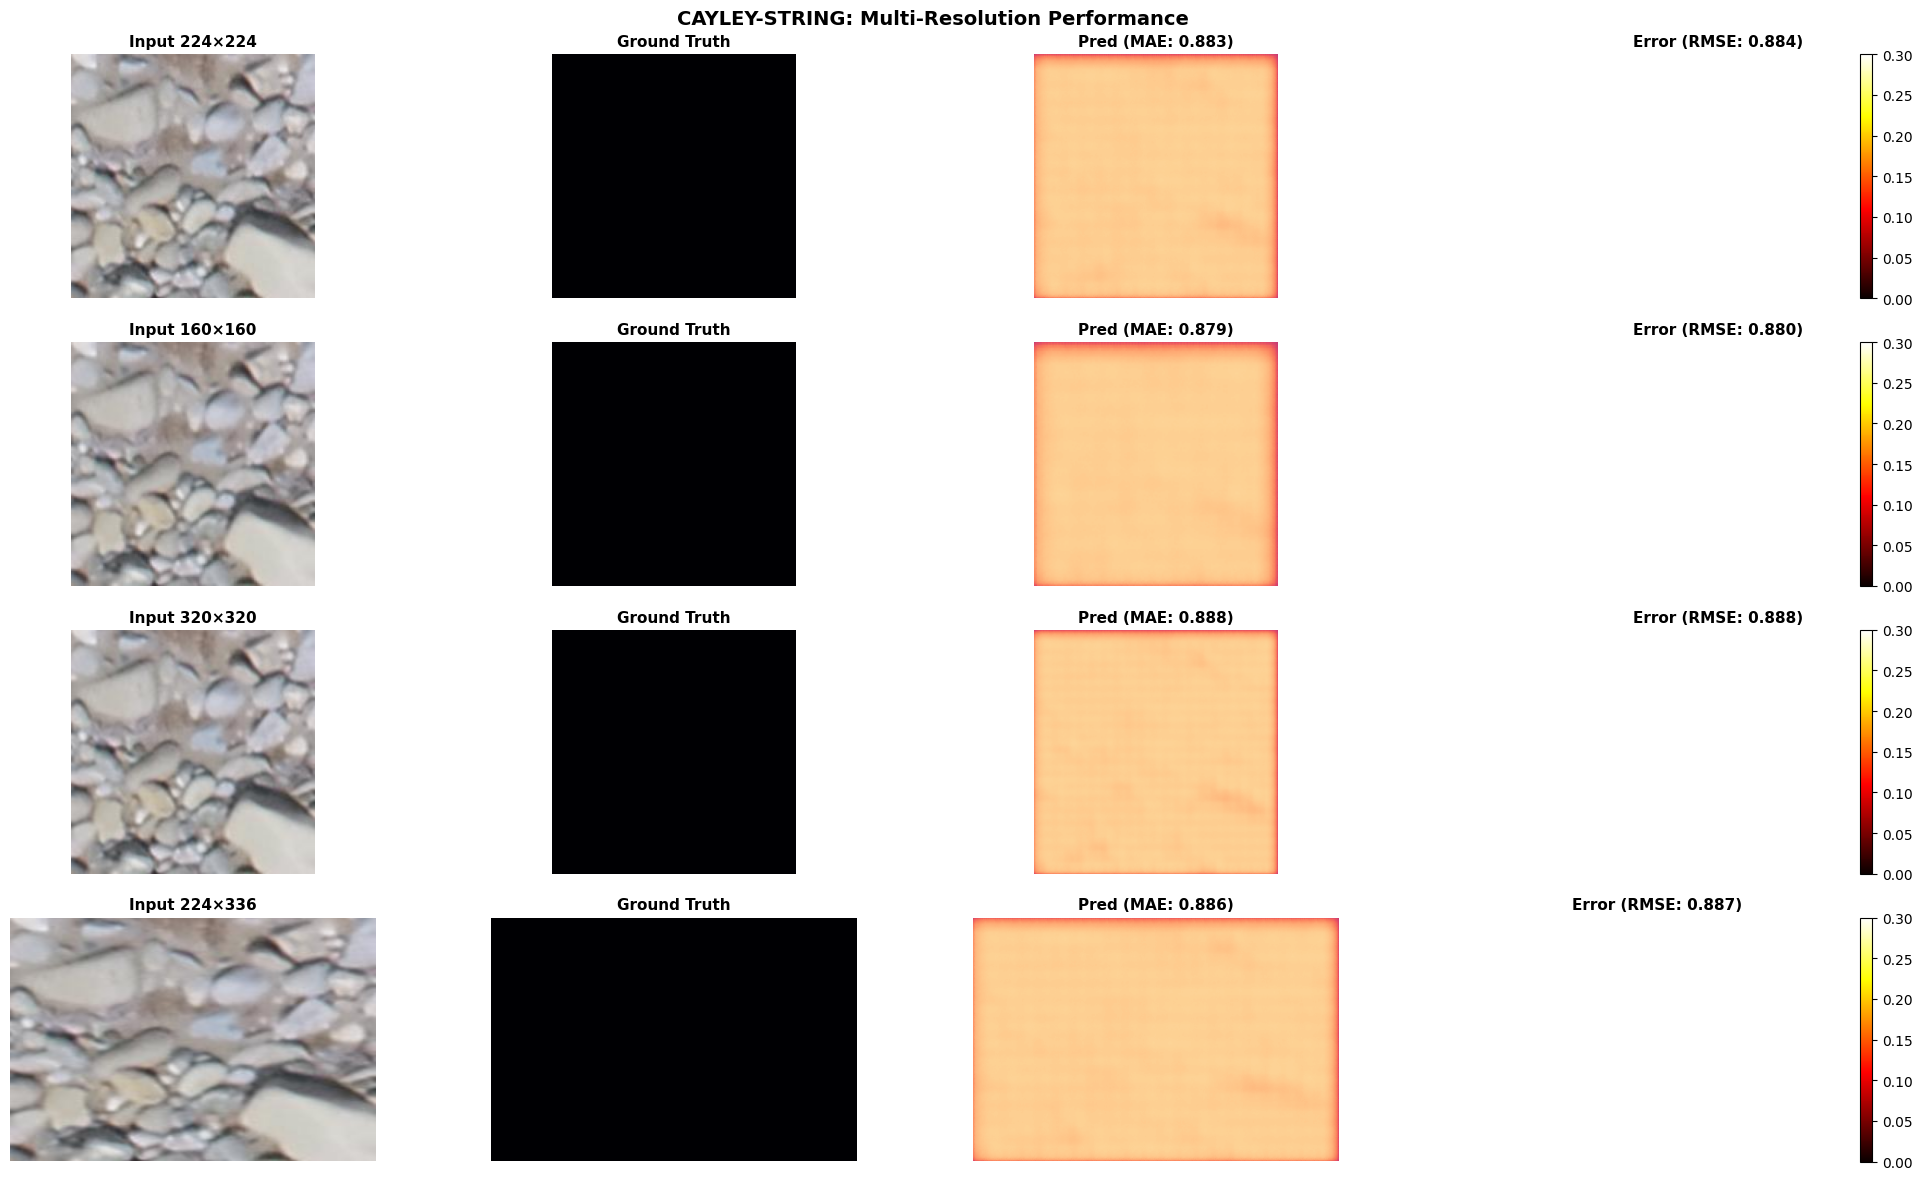


📊 Saved to: outputs/multires_cayley_4L.png

🔬 Extreme Resolution Test: CAYLEY-STRING
✓ 96×96: 0.081s, range=[0.535, 0.910]
✓ 512×512: 0.085s, range=[0.535, 0.915]
✓ 128×384: 0.082s, range=[0.535, 0.912]
✓ 384×128: 0.080s, range=[0.535, 0.910]

📊 Summary:
Size         Time (s)   Status     Output Shape
------------------------------------------------------------
96×96       0.081      OK         (1, 96, 96, 1)
512×512      0.085      OK         (1, 512, 512, 1)
128×384      0.082      OK         (1, 128, 384, 1)
384×128      0.080      OK         (1, 384, 128, 1)


In [51]:
detailed_analysis(cayley_config, "./data/input_frames/grain_0011.jpg")
test_multi_resolution(cayley_config, "./data/input_frames/grain_0011.jpg")
test_extreme_resolutions(cayley_config, "./data/input_frames/grain_0011.jpg")

In [ ]:
# @title ## view uning plotly to view interactively

import plotly.graph_objects as go
import numpy as np
import cv2

# Configuration
data_dir = '/content/vision_transformer_depth/data'

tile_idx = 200 # @param {"type":"integer","placeholder":"0"}
z_scale = 1 # @param {"type":"integer","placeholder":"0"}

# Load tile
rgb_path = f'{data_dir}/input_frames/frame_{tile_idx:04d}.png'
depth_path = f'{data_dir}/depth_maps/frame_{tile_idx:04d}.png'

rgb_img = cv2.cvtColor(cv2.imread(rgb_path), cv2.COLOR_BGR2RGB)
depth_img = cv2.imread(depth_path, cv2.IMREAD_GRAYSCALE)

h, w = depth_img.shape
z = depth_img.astype(float) * z_scale

# Create interactive 3D surface
fig = go.Figure(data=[go.Surface(
    z=z,
    surfacecolor=rgb_img[:, :, 0],  # Use R channel for coloring
    colorscale='Viridis',
    showscale=False
)])

fig.update_layout(
    title=f'Terrain Tile {tile_idx}',
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Elevation',
        aspectmode='manual',
        aspectratio=dict(x=1, y=1, z=0.3)
    ),
    # width=800,
    # height=700
)

fig.show()
print(f"✅ Interactive tile {tile_idx} - Rotate/zoom with mouse!")